# Survey, Eye-Tracking EDA, and Model-Human Attention Alignment

This notebook builds a single exploratory report for the subjective safety survey and the eye-tracking subset.

Main sections:

1. Respondent profiles and survey answers.
2. Eye-tracking EDA from `aoi.txt`, `stats_fixations.txt`, `stats_saccades.txt`, `stats_standard.txt`, and raw OGAMA exports.
3. Object-level analyses: area, attention, first looks, area-normalized attention, transitions, and safe/unsafe associations.
4. Ranking-branch CNN Grad-CAM vs human gaze alignment using `models/vgg_syn+ber.pt` on `splits/comparisons_df_test.pkl`.
5. Quick visual checks: one random Grad-CAM heatmap and one random AOI-outline trial.

### 0.1 Imports, Paths, and Geometry

Set up imports, random seeds, project paths, output folders, and the OGAMA display geometry used throughout the notebook.


In [1]:
# Core imports and configuration
from __future__ import annotations

import os
import re
import math
import json
import zipfile
import random
import warnings
from pathlib import Path
from collections import defaultdict

import numpy as np
import pandas as pd
from PIL import Image, ImageDraw

import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore", category=FutureWarning)

try:
    from IPython.display import display
except Exception:
    display = print

SEED = 30
random.seed(SEED)
np.random.seed(SEED)

sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_columns", 160)
pd.set_option("display.width", 160)

REPO_ROOT = Path("/home/csantiago").resolve()
ANALYSIS_DIR = REPO_ROOT / "Analysis"
OUT_DIR = ANALYSIS_DIR / "results" / "eyetracking_survey_eda"
OUT_DIR.mkdir(parents=True, exist_ok=True)
EDA_FIG_DIR = ANALYSIS_DIR / "results_eda"
EDA_FIG_DIR.mkdir(parents=True, exist_ok=True)

SURVEY_DIR = REPO_ROOT / "survey_eye_tracker"
PROFILES_CSV = SURVEY_DIR / "cycling_profiles.csv"
SURVEY_RESULTS_CSV = SURVEY_DIR / "results-survey115192.csv"
EYE_ZIP = REPO_ROOT / "eye_tracker_data_dataexported.zip"
EYE_ROOT = SURVEY_DIR / "eye_tracker_data"

TEST_PKL = REPO_ROOT / "splits" / "comparisons_df_test.pkl"
DATASET_ROOT = REPO_ROOT / "images" / "printart" / "subjectivesafety_images"
GAZE_ROOT_864 = SURVEY_DIR / "Eyetracker_attention_maps" / "864x508"
CHECKPOINT = REPO_ROOT / "models" / "vgg_syn+ber.pt"

AOI_TRIAL_OFFSET = 1  # TrialID in aoi.txt maps to TrialID+1 in fixation/saccade/standard logs
PROFILE_LABELS = {
    "NWNH": "No Way, No How",
    "IC": "Interested but Concerned",
    "EC": "Enthused and Confident",
    "SF": "Strong and Fearless",
}
AO_SCORE_LABELS = {f"AO{i:02d}": f"AO{i:02d} (score {i})" for i in range(1, 8)}

# OGAMA stimulus geometry from ui_params.json / previous notebooks.
SCREEN_W, SCREEN_H = 1920, 1200
DISPLAY_SINGLE_W, DISPLAY_SINGLE_H = 864, 508
LEFT_X_OFFSET, LEFT_Y_OFFSET = 76, 225
RIGHT_X_OFFSET, RIGHT_Y_OFFSET = 979, 225

# Extraction is off by default because the data already exists in survey_eye_tracker/eye_tracker_data.
# Switch this to True if you need to rebuild the extracted folder from the zip.
EXTRACT_EYE_TRACKER_ZIP = False

# Scope for the eye-tracking EDA:
#   "profiled"     -> only subjects listed in cycling_profiles.csv
#   "all_cycling"  -> every cycling... subject session
#   "all_sessions" -> every session folder under EYE_ROOT
RESPONDENT_FILTER = "profiled"

print("Output folder:", OUT_DIR)
print("Standalone EDA figure folder:", EDA_FIG_DIR)
print("Eye root exists:", EYE_ROOT.exists())
print("Gaze map root exists:", GAZE_ROOT_864.exists())
print("Checkpoint exists:", CHECKPOINT.exists())

Output folder: /home/csantiago/Analysis/results/eyetracking_survey_eda
Eye root exists: True
Gaze map root exists: True
Checkpoint exists: True


## 1. Respondent Profiles and Survey Answers

### 1.1 Load Respondent Tables

Load `cycling_profiles.csv` and the LimeSurvey results, clean column names, preview the data, and save clean copies.


In [2]:
def clean_columns(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()
    out.columns = [
        str(c).replace("\ufeff", "").strip().strip('"').strip("'")
        for c in out.columns
    ]
    return out


profiles = clean_columns(pd.read_csv(PROFILES_CSV))
survey = clean_columns(pd.read_csv(SURVEY_RESULTS_CSV, sep=None, engine="python"))

profiles["subject"] = profiles["subject"].astype(str).str.strip()
profiles["profile"] = profiles["profile"].astype(str).str.strip()
profiles["profile_label"] = profiles["profile"].map(PROFILE_LABELS).fillna(profiles["profile"])

print("profiles:", profiles.shape)
print("survey results:", survey.shape)

display(profiles.head())
display(survey.head())

profiles.to_csv(OUT_DIR / "respondent_profiles_clean.csv", index=False)
survey.to_csv(OUT_DIR / "survey_results_clean.csv", index=False)

profiles: (26, 7)
survey results: (30, 59)


,subject,NWNH,IC,EC,SF,profile,profile_label
0,cycling932844b29e6175a85d195cbee96ce34057d0b2c...,0,1,0,0,IC,Interested but Concerned
1,cycling132c5e4c5b0a45e274e7fb849fecd22e62edf40...,0,1,0,0,IC,Interested but Concerned
2,cycling0a3df224a10f3472c2a9c568a927406a49b0121...,1,0,0,0,NWNH,"No Way, No How"
3,cyclingbd1af6d2f4bda83c3d5d6dfc93817421d804a64...,0,0,1,0,EC,Enthused and Confident
4,cycling28b744c8c0b8b330c7f678d5b23aa2ce614a5ae...,0,1,0,0,IC,Interested but Concerned


,id,submitdate,lastpage,startlanguage,seed,startdate,datestamp,TermsOfConsent,Consent,Enthusiasm,Frequency,Experience,WhenCycling[SQ001],WhenCycling[SQ002],Purpose[SQ003],Purpose[SQ004],Purpose[SQ005],Purpose[SQ006],Purpose[SQ007],Purpose[SQ008],AutoAssessment04,AutoAssessment05,Roads50kmhCyclingLan[SQ001],Roads50kmh[SQ001],ResidentialHigh01[SQ001],ResidentialLow01[SQ001],Segregated01[SQ001],Age,Gender,Location,rdmvalue,rdmcode,code,interviewtime,groupTime121,TermsOfConsentTime,ConsentTime,groupTime118,EnthusiasmTime,FrequencyTime,ExperienceTime,WhenCyclingTime,PurposeTime,AutoAssessment04Time,AutoAssessment05Time,groupTime119,Roads50kmhCyclingLanTime,Roads50kmhTime,ResidentialHigh01Time,ResidentialLow01Time,Segregated01Time,groupTime120,AgeTime,GenderTime,LocationTime,groupTime122,rdmvalueTime,rdmcodeTime,codeTime
0,14,NaN,1.0,en,682657950,2022-10-10 08:54:10,2022-10-10 08:54:52,NaN,Y,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,41.77,41.77,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,15,2022-10-10 08:58:59,5.0,en,1296613888,2022-10-10 08:58:20,2022-10-10 08:58:59,NaN,Y,AO04,AO04,AO03,NaN,Y,Y,NaN,NaN,NaN,NaN,NaN,NaN,NaN,AO07,AO07,AO07,AO07,AO07,Age02,Gen01,55.67594;12.56553,NaN,NaN,NaN,38.73,4.73,NaN,NaN,10.72,NaN,NaN,NaN,NaN,NaN,NaN,NaN,10.94,NaN,NaN,NaN,NaN,NaN,12.34,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,16,2022-10-10 11:51:27,5.0,en,968139336,2022-10-10 11:49:21,2022-10-10 11:51:27,NaN,Y,AO05,AO04,AO02,Y,Y,Y,NaN,Y,Y,NaN,NaN,NaN,NaN,AO02,AO01,AO01,AO04,AO07,Age03,Gen01,55.67594;12.56553,NaN,NaN,NaN,126.31,31.67,NaN,NaN,40.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,34.58,NaN,NaN,NaN,NaN,NaN,20.06,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,17,2022-10-10 12:42:48,5.0,en,275886623,2022-10-10 12:40:01,2022-10-10 12:42:48,NaN,Y,AO04,AO04,AO02,Y,Y,Y,NaN,Y,Y,NaN,Y,NaN,NaN,AO05,AO03,AO04,AO04,AO06,Age03,Gen01,55.67594;12.56553,NaN,NaN,NaN,166.13,58.32,NaN,NaN,33.38,NaN,NaN,NaN,NaN,NaN,NaN,NaN,50.41,NaN,NaN,NaN,NaN,NaN,24.02,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,18,NaN,NaN,en,1536079419,2022-10-18 12:50:45,2022-10-18 12:50:45,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### 1.2 Profile Distribution
Summarize the cycling profile groups created in `05.CyclingProfiles.ipynb`: `NWNH` means **No Way, No How**, `IC` means **Interested but Concerned**, `EC` means **Enthused and Confident**, and `SF` means **Strong and Fearless**. The survey answer codes `AO01` to `AO07` are the seven ordered answer choices used by the raw survey export; the profile notebook converts them to numeric scores `AO01=1`, ..., `AO07=7` before applying the profile rules.


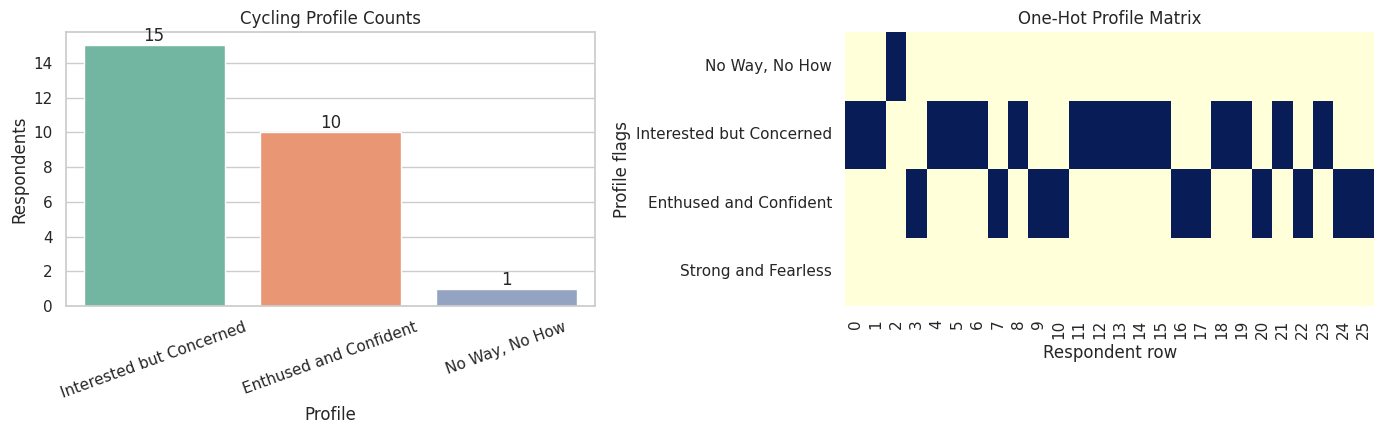

,profile,n
0,Interested but Concerned,15
1,Enthused and Confident,10
2,"No Way, No How",1


In [3]:
# Profile distribution and respondent-profile matrix
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

profile_counts = profiles["profile_label"].value_counts().sort_values(ascending=False)
sns.barplot(x=profile_counts.index, y=profile_counts.values, ax=axes[0], palette="Set2")
axes[0].set_title("Cycling Profile Counts")
axes[0].set_xlabel("Profile")
axes[0].set_ylabel("Respondents")
axes[0].tick_params(axis="x", rotation=20)
for i, v in enumerate(profile_counts.values):
    axes[0].text(i, v, str(v), ha="center", va="bottom")

profile_cols = [c for c in ["NWNH", "IC", "EC", "SF"] if c in profiles.columns]
profile_matrix = profiles[profile_cols].apply(pd.to_numeric, errors="coerce").fillna(0)
sns.heatmap(
    profile_matrix.T,
    cmap="YlGnBu",
    cbar=False,
    ax=axes[1],
    yticklabels=[PROFILE_LABELS.get(c, c) for c in profile_cols],
)
axes[1].set_title("One-Hot Profile Matrix")
axes[1].set_xlabel("Respondent row")
axes[1].set_ylabel("Profile flags")

plt.tight_layout()
plt.savefig(OUT_DIR / "respondent_profile_distribution.png", dpi=180, bbox_inches="tight")
plt.show()

display(profile_counts.rename_axis("profile").reset_index(name="n"))


### 1.3 Survey Answer Overview

Separate real answer fields from timing/admin fields, summarize response coverage, and plot useful categorical distributions.


,question,answered_n,missing_n,unique_answers,top_answer,top_answer_n
1,Consent,28,2,1,Y,28
22,Location,27,3,15,55.67594;12.56553,13
16,Roads50kmh[SQ001],27,3,7,AO02,10
17,ResidentialHigh01[SQ001],27,3,7,AO03,8
18,ResidentialLow01[SQ001],27,3,7,AO04,9
3,Frequency,27,3,5,AO04,10
15,Roads50kmhCyclingLan[SQ001],27,3,5,AO05,10
2,Enthusiasm,27,3,4,AO05,12
19,Segregated01[SQ001],27,3,3,AO07,21
20,Age,27,3,3,Age02,15


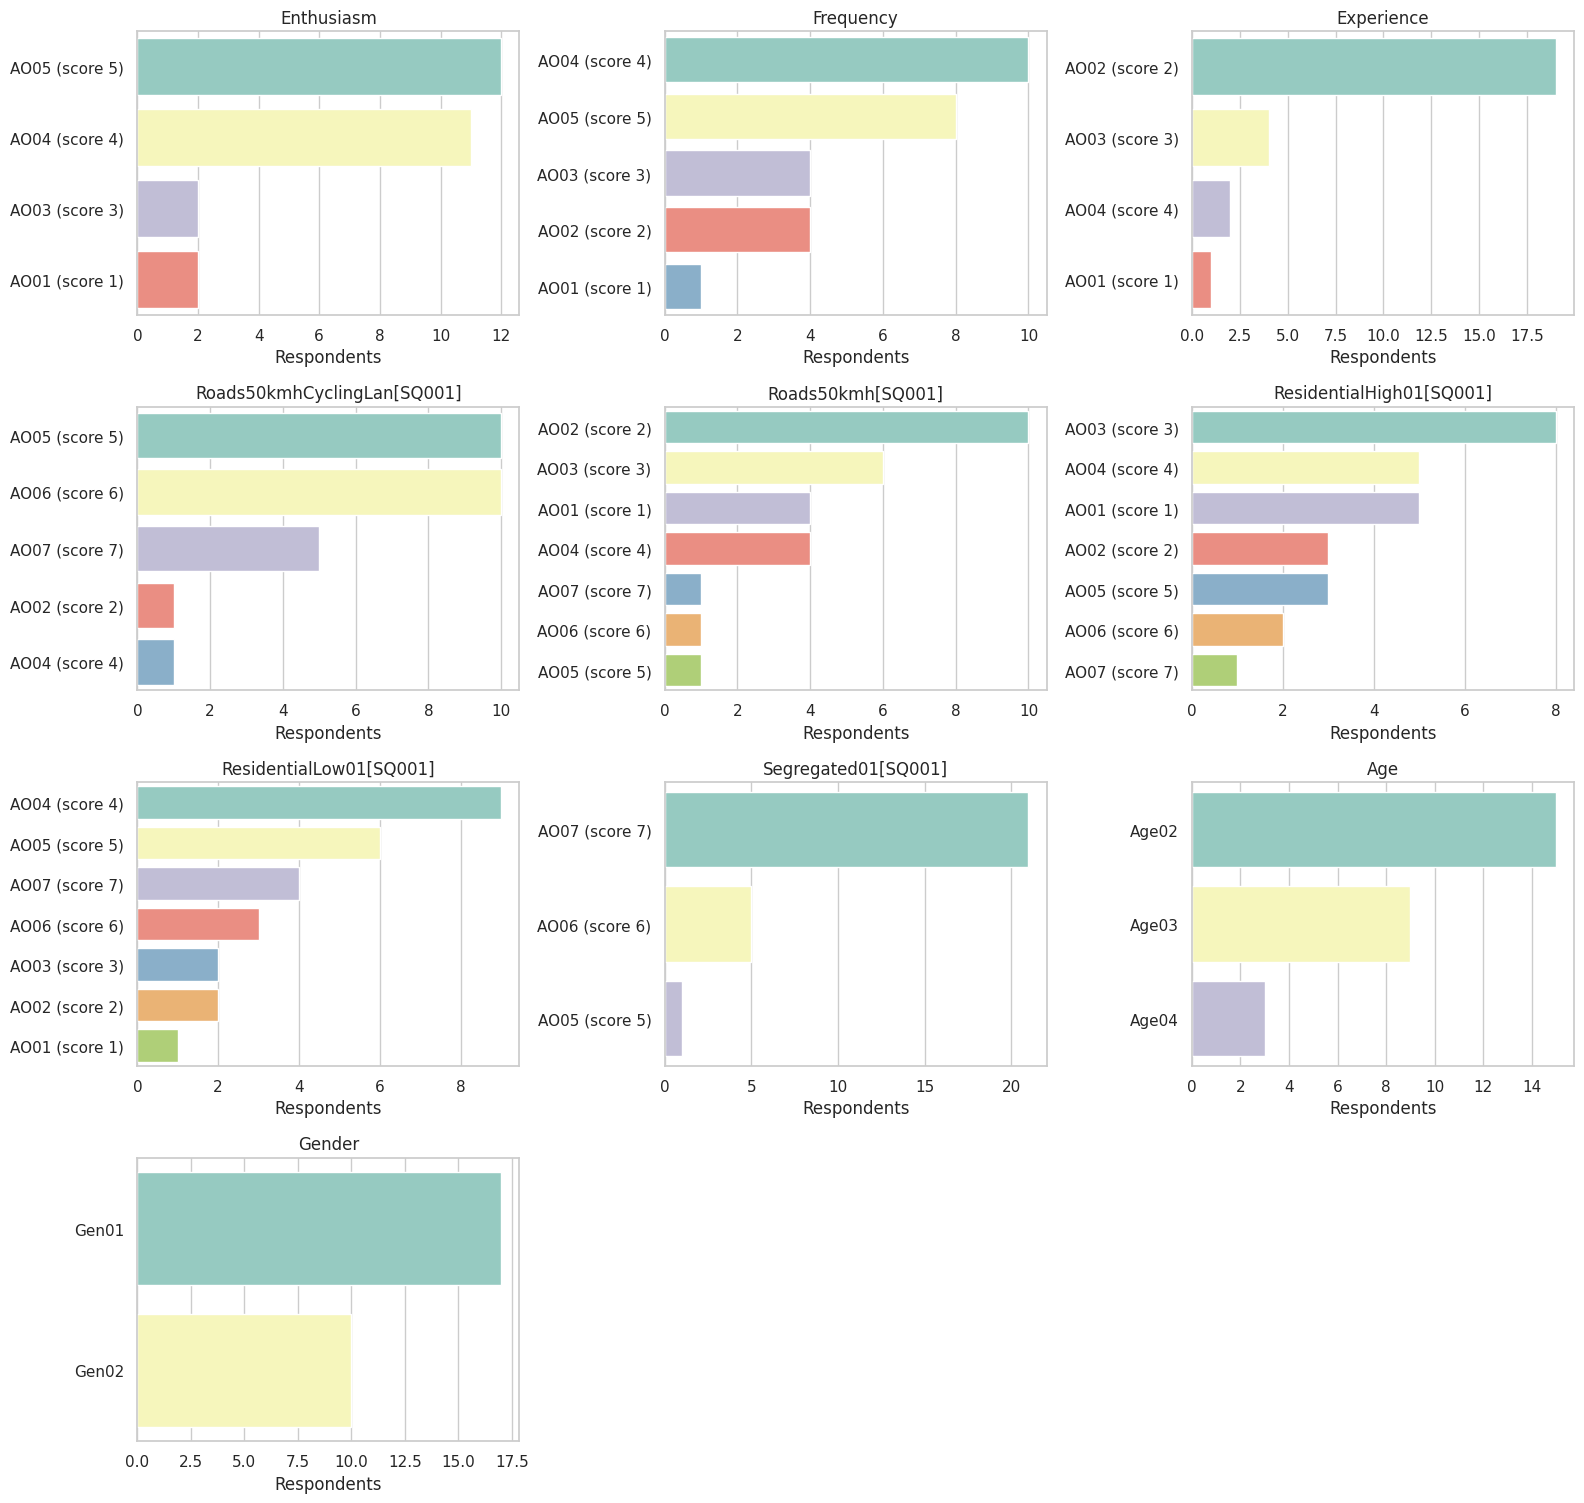

In [4]:
# Survey answer EDA.
# The LimeSurvey file has many timing/admin fields, so this keeps direct respondent answers.
admin_patterns = ("time", "date", "seed", "lastpage", "startlanguage", "submitdate", "datestamp")
exclude_exact = {"id", "rdmvalue", "rdmcode", "code"}

answer_cols = []
for c in survey.columns:
    lc = str(c).lower()
    if c in exclude_exact:
        continue
    if any(p in lc for p in admin_patterns):
        continue
    answer_cols.append(c)

answer_summary_rows = []
for c in answer_cols:
    s = survey[c].replace("", np.nan).dropna()
    answer_summary_rows.append({
        "question": c,
        "answered_n": int(s.shape[0]),
        "missing_n": int(survey.shape[0] - s.shape[0]),
        "unique_answers": int(s.astype(str).nunique()),
        "top_answer": s.astype(str).value_counts().index[0] if len(s) else np.nan,
        "top_answer_n": int(s.astype(str).value_counts().iloc[0]) if len(s) else 0,
    })

answer_summary = pd.DataFrame(answer_summary_rows).sort_values(["answered_n", "unique_answers"], ascending=[False, False])
answer_summary.to_csv(OUT_DIR / "survey_answer_summary.csv", index=False)
display(answer_summary.head(30))

plot_cols = [
    c for c in answer_cols
    if 1 < survey[c].dropna().astype(str).nunique() <= 12 and survey[c].dropna().shape[0] >= 5
]
plot_cols = plot_cols[:12]

if plot_cols:
    ncols = 3
    nrows = math.ceil(len(plot_cols) / ncols)
    fig, axes = plt.subplots(nrows, ncols, figsize=(16, 3.8 * nrows))
    axes = np.array(axes).reshape(-1)
    for ax, c in zip(axes, plot_cols):
        vc = survey[c].dropna().astype(str).value_counts().head(12)
        answer_labels = [AO_SCORE_LABELS.get(v, v) for v in vc.index]
        sns.barplot(y=answer_labels, x=vc.values, ax=ax, palette="Set3")
        ax.set_title(c)
        ax.set_xlabel("Respondents")
        ax.set_ylabel("")
    for ax in axes[len(plot_cols):]:
        ax.axis("off")
    plt.tight_layout()
    plt.savefig(OUT_DIR / "survey_answer_distributions.png", dpi=180, bbox_inches="tight")
    plt.show()

## 2. Extract and Load All Eye-Tracking Export Tables

### 2.1 Discover Eye-Tracking Sessions

Define the expected OGAMA export files, optionally extract them from the zip, and discover the participant sessions to include.


In [5]:
EXPORT_FILES = {
    "aoi": ["aoi.txt"],
    "fixations": ["stats_fixations.txt", "stats_fications.txt"],  # one session has the typo
    "saccades": ["stats_saccades.txt"],
    "standard": ["stats_standard.txt"],
    "raw": ["ogama_data.txt"],
}


def extract_eye_tracker_zip(zip_path: Path, target_root: Path, overwrite: bool = False) -> None:
    if not zip_path.exists():
        raise FileNotFoundError(zip_path)
    target_root.parent.mkdir(parents=True, exist_ok=True)
    wanted_names = {name for names in EXPORT_FILES.values() for name in names}
    extra_names = {"comparisons.csv", "ui_params.json", "scores.csv"}

    with zipfile.ZipFile(zip_path) as zf:
        members = []
        for info in zf.infolist():
            base = Path(info.filename).name
            if base in wanted_names or base in extra_names or re.match(r"^\d+-.*\.(png|jpg|jpeg)$", base, re.I):
                members.append(info)

        print(f"Extracting {len(members)} export/screenshot files from {zip_path.name} ...")
        for info in members:
            out_path = target_root.parent / info.filename
            if out_path.exists() and not overwrite:
                continue
            zf.extract(info, path=target_root.parent)


if EXTRACT_EYE_TRACKER_ZIP or not EYE_ROOT.exists():
    extract_eye_tracker_zip(EYE_ZIP, EYE_ROOT, overwrite=False)


def discover_sessions(root: Path, respondent_filter: str = "profiled") -> list[Path]:
    if not root.exists():
        raise FileNotFoundError(root)

    profile_subjects = set(profiles["subject"].astype(str)) if "profiles" in globals() else set()
    sessions = []
    for p in sorted(root.glob("*/*")):
        if not p.is_dir():
            continue
        survey_id = p.parent.name
        if respondent_filter == "profiled" and survey_id not in profile_subjects:
            continue
        if respondent_filter == "all_cycling" and not survey_id.startswith("cycling"):
            continue
        if any((p / name).exists() for names in EXPORT_FILES.values() for name in names):
            sessions.append(p)
    return sessions


sessions = discover_sessions(EYE_ROOT, RESPONDENT_FILTER)
print("sessions:", len(sessions), "| filter:", RESPONDENT_FILTER)
display(pd.DataFrame({
    "session": [str(p.relative_to(EYE_ROOT)) for p in sessions[:10]],
    "files": [", ".join(sorted(x.name for x in p.glob("*.txt"))) for p in sessions[:10]],
}))

sessions: 23 | filter: profiled


,session,files
0,cycling08ab6849b6ce9851d50c230e82c8b2ba0564ffc...,"aoi.txt, ogama_data.txt, stats_fixations.txt, ..."
1,cycling0a3df224a10f3472c2a9c568a927406a49b0121...,"aoi.txt, ogama_data.txt, stats_fixations.txt, ..."
2,cycling132c5e4c5b0a45e274e7fb849fecd22e62edf40...,"aoi.txt, ogama_data.txt, stats_fixations.txt, ..."
3,cycling145b3ad29cb766fb22e4cfba1d750db8c17470b...,"aoi.txt, ogama_data.txt, stats_fixations.txt, ..."
4,cycling14fd071ffaf930135bd748b9623a06847a49559...,"aoi.txt, ogama_data.txt, stats_fixations.txt, ..."
5,cycling2846319a17ec7fcad28ab540e7a7b18c9432e63...,"aoi.txt, ogama_data.txt"
6,cycling28b744c8c0b8b330c7f678d5b23aa2ce614a5ae...,"aoi.txt, ogama_data.txt, stats_fixations.txt, ..."
7,cycling469572b0c7fe5cc0c5f020ebae513ffeae62ec4...,"aoi.txt, ogama_data.txt, stats_fixations.txt, ..."
8,cycling4c845f8ebd5f514f1fdc690d2ab60d5f8beb818...,"aoi.txt, ogama_data.txt, stats_aoi.txt, stats_..."
9,cycling4eea1bbed89e15ea4b3ecbc10b941272711810e...,"aoi.txt, ogama_data.txt, stats_fixations.txt, ..."


### 2.2 Load OGAMA Export Tables

Read AOIs, fixations, saccades, standard trial statistics, and compact summaries of the large raw gaze files.


In [6]:
def read_ogama_table(path: Path) -> pd.DataFrame:
    # Read tab-separated OGAMA exports while ignoring comment lines.
    if not path.exists():
        return pd.DataFrame()
    try:
        df = pd.read_csv(path, sep="\t", comment="#", engine="python", dtype=str, keep_default_na=False)
    except pd.errors.EmptyDataError:
        return pd.DataFrame()
    df.columns = [str(c).strip() for c in df.columns]
    return df.loc[:, [c for c in df.columns if str(c).strip() != ""]]


def first_existing(session: Path, names: list[str]) -> Path | None:
    for name in names:
        p = session / name
        if p.exists():
            return p
    return None


def load_export_kind(kind: str, sessions: list[Path]) -> pd.DataFrame:
    rows = []
    for session in sessions:
        p = first_existing(session, EXPORT_FILES[kind])
        if p is None:
            continue
        df = read_ogama_table(p)
        if df.empty:
            continue
        df["survey_id"] = session.parent.name
        df["session_dir"] = str(session.relative_to(EYE_ROOT))
        df["source_file"] = p.name
        rows.append(df)
    return pd.concat(rows, ignore_index=True) if rows else pd.DataFrame()


aoi_raw = load_export_kind("aoi", sessions)
fix_raw = load_export_kind("fixations", sessions)
sacc_raw = load_export_kind("saccades", sessions)
standard_raw = load_export_kind("standard", sessions)

# Raw OGAMA files are large; keep a compact per-session summary instead of loading millions of gaze samples.
raw_summaries = []
for session in sessions:
    p = first_existing(session, EXPORT_FILES["raw"])
    if p is None:
        continue
    raw_summaries.append({
        "survey_id": session.parent.name,
        "session_dir": str(session.relative_to(EYE_ROOT)),
        "raw_file": p.name,
        "raw_size_mb": p.stat().st_size / 1024**2,
    })
raw_summary = pd.DataFrame(raw_summaries)

exports_summary = pd.DataFrame([
    {"table": "aoi", "rows": len(aoi_raw), "sessions": aoi_raw["session_dir"].nunique() if len(aoi_raw) else 0},
    {"table": "stats_fixations", "rows": len(fix_raw), "sessions": fix_raw["session_dir"].nunique() if len(fix_raw) else 0},
    {"table": "stats_saccades", "rows": len(sacc_raw), "sessions": sacc_raw["session_dir"].nunique() if len(sacc_raw) else 0},
    {"table": "stats_standard", "rows": len(standard_raw), "sessions": standard_raw["session_dir"].nunique() if len(standard_raw) else 0},
    {"table": "ogama_data", "rows": np.nan, "sessions": len(raw_summary)},
])

display(exports_summary)
display(raw_summary.head())

exports_summary.to_csv(OUT_DIR / "eyetracking_export_summary.csv", index=False)
raw_summary.to_csv(OUT_DIR / "ogama_raw_file_summary.csv", index=False)

,table,rows,sessions
0,aoi,77270.0,23
1,stats_fixations,33705.0,22
2,stats_saccades,32275.0,22
3,stats_standard,1320.0,20
4,ogama_data,NaN,23


,survey_id,session_dir,raw_file,raw_size_mb
0,cycling08ab6849b6ce9851d50c230e82c8b2ba0564ffc...,cycling08ab6849b6ce9851d50c230e82c8b2ba0564ffc...,ogama_data.txt,6.240204
1,cycling0a3df224a10f3472c2a9c568a927406a49b0121...,cycling0a3df224a10f3472c2a9c568a927406a49b0121...,ogama_data.txt,5.967773
2,cycling132c5e4c5b0a45e274e7fb849fecd22e62edf40...,cycling132c5e4c5b0a45e274e7fb849fecd22e62edf40...,ogama_data.txt,8.919285
3,cycling145b3ad29cb766fb22e4cfba1d750db8c17470b...,cycling145b3ad29cb766fb22e4cfba1d750db8c17470b...,ogama_data.txt,9.984555
4,cycling14fd071ffaf930135bd748b9623a06847a49559...,cycling14fd071ffaf930135bd748b9623a06847a49559...,ogama_data.txt,7.459260


## 3. Eye-Tracking Object EDA

### 3.1 Normalize Fixation Objects

Clean fixation records, infer left/right image side, and expand multi-label AOI groups into object-level rows.


In [7]:
def to_num(s, default=np.nan):
    return pd.to_numeric(s, errors="coerce").fillna(default)


def infer_side_from_name(x: str) -> str | None:
    s = str(x).lower()
    if "imageleft" in s or s.startswith("left"):
        return "left"
    if "imageright" in s or s.startswith("right"):
        return "right"
    return None


def clean_object_label(x: str) -> str:
    s = str(x).strip().lower()
    s = s.replace("_", " ").replace("-", " ")
    s = " ".join(s.split())
    if s in {"", "nan", "none"}:
        return "unknown"
    return s


def split_object_labels(x: str) -> list[str]:
    labels = [clean_object_label(v) for v in str(x).split("#")]
    labels = [v for v in labels if v not in {"", "unknown"}]
    return labels if labels else ["unknown"]


def normalize_fixations(df: pd.DataFrame) -> pd.DataFrame:
    if df.empty:
        return df
    out = pd.DataFrame({
        "survey_id": df["survey_id"].astype(str),
        "session_dir": df["session_dir"].astype(str),
        "subject_name": df.get("SubjectName", "").astype(str),
        "trial_id": to_num(df.get("TrialID", -1), -1).astype(int),
        "trial_sequence": to_num(df.get("TrialSequence", -1), -1).astype(int),
        "count_in_trial": to_num(df.get("CountInTrial", -1), -1).astype(int),
        "start_time": to_num(df.get("StartTime", 0), 0).astype(float),
        "duration": to_num(df.get("Length", 0), 0).astype(float),
        "pos_x": to_num(df.get("PosX", np.nan), np.nan).astype(float),
        "pos_y": to_num(df.get("PosY", np.nan), np.nan).astype(float),
        "aoi": df.get("AOI", "").astype(str),
        "aoi_group": df.get("AOI group", "").astype(str),
    })
    out["side"] = out["aoi"].apply(infer_side_from_name)
    out["object_group"] = out["aoi_group"].where(out["aoi_group"].astype(str).str.len() > 0, out["aoi"])
    return out


def explode_fixation_objects(fix: pd.DataFrame) -> pd.DataFrame:
    rows = []
    for _, r in fix.iterrows():
        labels = split_object_labels(r["object_group"])
        w = 1.0 / len(labels)
        for obj in labels:
            nr = r.to_dict()
            nr["object"] = obj
            nr["object_weight"] = w
            nr["duration_weighted"] = float(r["duration"]) * w
            nr["count_weighted"] = w
            rows.append(nr)
    return pd.DataFrame(rows)


fix = normalize_fixations(fix_raw)
fix_long = explode_fixation_objects(fix)
fix_long = fix_long[fix_long["trial_id"] >= 0].copy()

ignore_objects = {"unknown", "nowhere", "nan", ""}
fix_valid = fix_long[~fix_long["object"].isin(ignore_objects)].copy()

print("fixations:", fix.shape)
print("exploded object fixations:", fix_long.shape)
display(fix_valid.head())

fixations: (33705, 14)
exploded object fixations: (33705, 18)


,survey_id,session_dir,subject_name,trial_id,trial_sequence,count_in_trial,start_time,duration,pos_x,pos_y,aoi,aoi_group,side,object_group,object,object_weight,duration_weighted,count_weighted
0,cycling08ab6849b6ce9851d50c230e82c8b2ba0564ffc...,cycling08ab6849b6ce9851d50c230e82c8b2ba0564ffc...,a36cd9b1bdd,1,1,1,0.0,4.0,458.803467,511.023010,imageleftroadf,road,left,road,road,1.0,4.0,1.0
3,cycling08ab6849b6ce9851d50c230e82c8b2ba0564ffc...,cycling08ab6849b6ce9851d50c230e82c8b2ba0564ffc...,a36cd9b1bdd,1,1,4,274.0,210.0,453.065277,552.165100,imageleftroadf,road,left,road,road,1.0,210.0,1.0
4,cycling08ab6849b6ce9851d50c230e82c8b2ba0564ffc...,cycling08ab6849b6ce9851d50c230e82c8b2ba0564ffc...,a36cd9b1bdd,1,1,5,818.0,5.0,1124.330200,495.700043,imagerightroada,road,right,road,road,1.0,5.0,1.0
5,cycling08ab6849b6ce9851d50c230e82c8b2ba0564ffc...,cycling08ab6849b6ce9851d50c230e82c8b2ba0564ffc...,a36cd9b1bdd,1,1,6,826.0,158.0,1414.119629,510.962555,imagerightsidewalke,sidewalk,right,sidewalk,sidewalk,1.0,158.0,1.0
6,cycling08ab6849b6ce9851d50c230e82c8b2ba0564ffc...,cycling08ab6849b6ce9851d50c230e82c8b2ba0564ffc...,a36cd9b1bdd,1,1,7,1017.0,289.0,1482.231445,541.202087,imagerightroada,road,right,road,road,1.0,289.0,1.0


### 3.2 Object Area From AOIs

Parse AOI polygons from `aoi.txt`, apply the one-trial alignment offset (`aoi.txt` TrialID -> other logs TrialID + 1), compute object areas, and rank objects by total occupied image area.


,object,area_px,n_shapes,area_share
9,road,444464050.0,5228,0.348090
17,vegetation,236210588.0,11310,0.184993
11,sky,224713287.5,6062,0.175988
1,building,177914100.5,13510,0.139337
10,sidewalk,72412969.0,8453,0.056712
3,car,50627293.5,6533,0.039650
12,terrain,20907177.5,4336,0.016374
4,fence,10917781.0,2889,0.008550
7,pole,9022337.5,8182,0.007066
18,wall,5048432.0,1276,0.003954


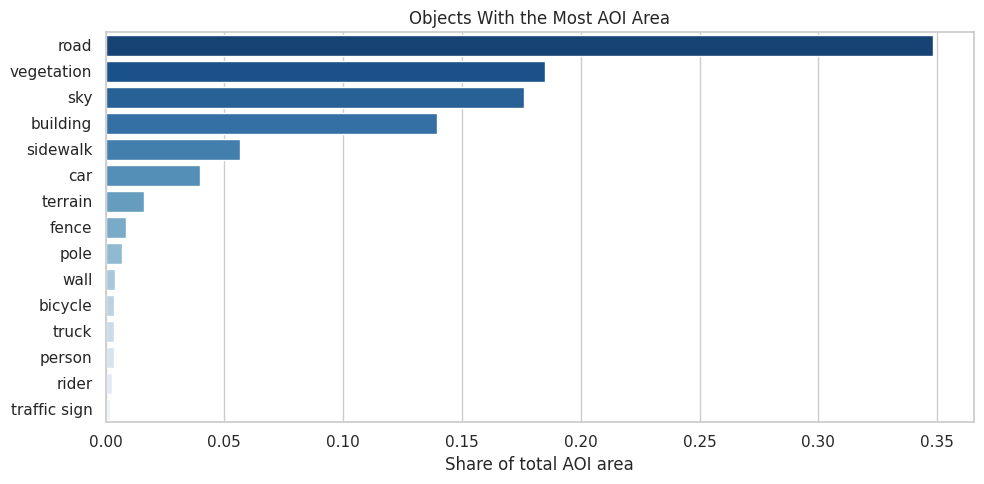

In [8]:
# AOI areas: compute polygon area from ShapePts because OGAMA's area-percent field is often zero.
POINT_RE = re.compile(r"P\d+:\(([-0-9.]+);([-0-9.]+)\)")


def parse_shape_points(text: str) -> list[tuple[float, float]]:
    pts = []
    for x, y in POINT_RE.findall(str(text)):
        pts.append((float(x), float(y)))
    return pts


def polygon_area(points: list[tuple[float, float]]) -> float:
    if len(points) < 3:
        return 0.0
    arr = np.asarray(points, dtype=float)
    x = arr[:, 0]
    y = arr[:, 1]
    return float(abs(np.dot(x, np.roll(y, -1)) - np.dot(y, np.roll(x, -1))) / 2.0)


def normalize_aoi(df: pd.DataFrame) -> pd.DataFrame:
    if df.empty:
        return df
    raw_trial_id = to_num(df.get("TrialID", -1), -1).astype(int)
    out = pd.DataFrame({
        "survey_id": df["survey_id"].astype(str),
        "session_dir": df["session_dir"].astype(str),
        "aoi_trial_id": raw_trial_id,
        "trial_id": raw_trial_id + int(AOI_TRIAL_OFFSET),
        "shape_name": df.get("ShapeName", "").astype(str),
        "shape_type": df.get("ShapeType", "").astype(str),
        "shape_group": df.get("ShapeGroup", "").astype(str),
        "shape_pts": df.get("ShapePts", "").astype(str),
    })
    out["side"] = out["shape_name"].apply(infer_side_from_name)
    out["object"] = out["shape_group"].apply(clean_object_label)
    out["points"] = out["shape_pts"].apply(parse_shape_points)
    out["area_px"] = out["points"].apply(polygon_area)
    out["area_frac_of_side"] = out["area_px"] / float(DISPLAY_SINGLE_W * DISPLAY_SINGLE_H)
    return out


aoi = normalize_aoi(aoi_raw)
aoi_valid = aoi[(aoi["trial_id"] >= 0) & (~aoi["object"].isin(ignore_objects)) & (aoi["area_px"] > 0)].copy()

area_by_object = (
    aoi_valid.groupby("object", as_index=False)
    .agg(area_px=("area_px", "sum"), n_shapes=("shape_name", "size"))
    .sort_values("area_px", ascending=False)
)
area_by_object["area_share"] = area_by_object["area_px"] / area_by_object["area_px"].sum()

display(area_by_object.head(20))
area_by_object.to_csv(OUT_DIR / "objects_by_total_aoi_area.csv", index=False)

fig, ax = plt.subplots(figsize=(10, 5))
top = area_by_object.head(15)
sns.barplot(data=top, y="object", x="area_share", ax=ax, palette="Blues_r")
ax.set_title("Objects With the Most AOI Area")
ax.set_xlabel("Share of total AOI area")
ax.set_ylabel("")
plt.tight_layout()
plt.savefig(OUT_DIR / "objects_most_area.png", dpi=180, bbox_inches="tight")
plt.show()

### 3.3 Object Attention and First Looks

Aggregate fixation duration/count by object and identify first-look objects overall and per image side.


,object,fixation_duration,fixation_count,respondents,trials,duration_share,count_share
9,road,3527214.0,14079.0,22,65,0.471806,0.470413
17,vegetation,1115291.0,4475.0,22,65,0.149183,0.149521
1,building,767977.0,3117.0,22,65,0.102726,0.104146
3,car,562841.0,2209.0,22,65,0.075287,0.073808
10,sidewalk,543644.0,2196.0,22,65,0.072719,0.073374
11,sky,372658.0,1504.0,22,65,0.049847,0.050252
12,terrain,145376.0,582.0,22,65,0.019446,0.019446
4,fence,90823.0,399.0,22,62,0.012149,0.013332
0,bicycle,59747.0,230.0,22,54,0.007992,0.007685
6,person,57294.0,229.0,22,57,0.007664,0.007651


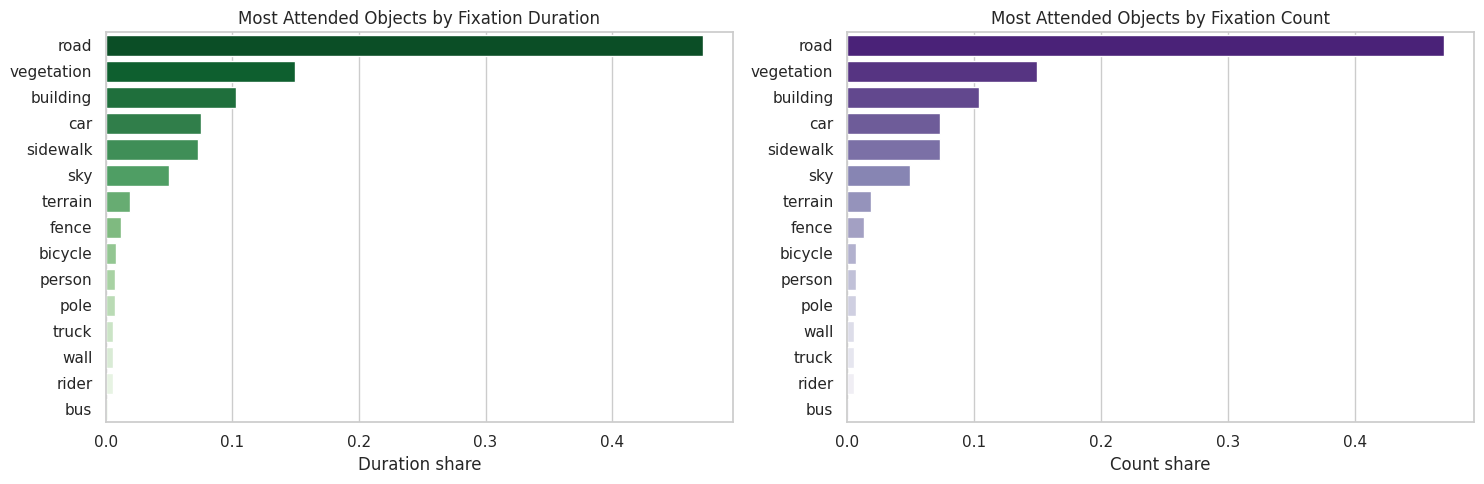

,object,first_look_count
0,road,602
1,vegetation,241
2,building,163
3,sidewalk,119
4,car,109
5,sky,68
6,fence,30
7,terrain,23
8,pole,15
9,person,12


,side,object,first_look_count
27,right,road,734
9,left,road,566
17,left,vegetation,209
34,right,vegetation,175
1,left,building,169
10,left,sidewalk,159
20,right,building,142
3,left,car,121
22,right,car,100
28,right,sidewalk,93


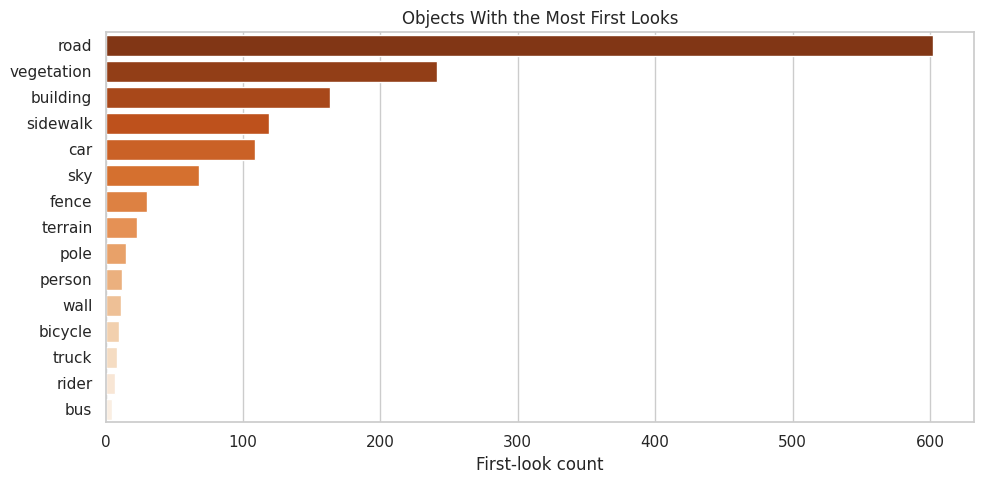

In [9]:
# Most attended objects and first looks
attn_by_object = (
    fix_valid.groupby("object", as_index=False)
    .agg(
        fixation_duration=("duration_weighted", "sum"),
        fixation_count=("count_weighted", "sum"),
        respondents=("survey_id", "nunique"),
        trials=("trial_id", "nunique"),
    )
    .sort_values("fixation_duration", ascending=False)
)
attn_by_object["duration_share"] = attn_by_object["fixation_duration"] / attn_by_object["fixation_duration"].sum()
attn_by_object["count_share"] = attn_by_object["fixation_count"] / attn_by_object["fixation_count"].sum()
attn_by_object.to_csv(OUT_DIR / "objects_most_attended.csv", index=False)
display(attn_by_object.head(20))

fig, ax = plt.subplots(figsize=(9, 5))
sns.barplot(data=attn_by_object.head(15), y="object", x="duration_share", ax=ax, palette="Greens_r")
ax.set_title("Most Attended Objects by Fixation Duration")
ax.set_xlabel("Duration share")
ax.set_ylabel("")
plt.tight_layout()
plt.savefig(EDA_FIG_DIR / "objects_most_attended_duration_share.png", dpi=220, bbox_inches="tight")
plt.show()

fig, ax = plt.subplots(figsize=(9, 5))
sns.barplot(data=attn_by_object.sort_values("fixation_count", ascending=False).head(15), y="object", x="count_share", ax=ax, palette="Purples_r")
ax.set_title("Most Attended Objects by Fixation Count")
ax.set_xlabel("Count share")
ax.set_ylabel("")
plt.tight_layout()
plt.savefig(EDA_FIG_DIR / "objects_most_attended_count_share.png", dpi=220, bbox_inches="tight")
plt.show()

# First look: first non-nowhere object per respondent/trial, plus first per side.
fix_for_first = fix_valid.sort_values(["survey_id", "trial_id", "start_time", "count_in_trial"]).copy()
first_overall = fix_for_first.groupby(["survey_id", "trial_id"], as_index=False).first()
first_by_side = fix_for_first.dropna(subset=["side"]).groupby(["survey_id", "trial_id", "side"], as_index=False).first()

first_overall_counts = first_overall["object"].value_counts().rename_axis("object").reset_index(name="first_look_count")
first_by_side_counts = first_by_side.groupby(["side", "object"]).size().reset_index(name="first_look_count").sort_values("first_look_count", ascending=False)

display(first_overall_counts.head(20))
display(first_by_side_counts.head(20))
first_overall_counts.to_csv(OUT_DIR / "objects_first_look_overall.csv", index=False)
first_by_side_counts.to_csv(OUT_DIR / "objects_first_look_by_side.csv", index=False)

fig, ax = plt.subplots(figsize=(10, 5))
sns.barplot(data=first_overall_counts.head(15), y="object", x="first_look_count", ax=ax, palette="Oranges_r")
ax.set_title("Objects With the Most First Looks")
ax.set_xlabel("First-look count")
ax.set_ylabel("")
plt.tight_layout()
plt.savefig(OUT_DIR / "objects_most_first_look.png", dpi=180, bbox_inches="tight")
plt.show()

### 3.4 Attention Relative to Area

Compare gaze share with area share to reveal small or medium objects that attract disproportionate attention.


,object,area_px,n_shapes,area_share,duration_share,count_share,fixation_duration,fixation_count,duration_to_area_ratio,count_to_area_ratio,log2_duration_area_enrichment
6,person,4401167.5,2751,0.003447,0.007664,0.007651,57294.0,229.0,2.223400,2.219831,1.152767
0,bicycle,4762261.0,1907,0.003730,0.007992,0.007685,59747.0,230.0,2.142788,2.060473,1.099489
2,bus,1268657.5,268,0.000994,0.002086,0.001838,15598.0,55.0,2.099909,1.849568,1.070327
8,rider,3696497.5,929,0.002895,0.005805,0.005780,43395.0,173.0,2.005052,1.996678,1.003639
3,car,50627293.5,6533,0.039650,0.075287,0.073808,562841.0,2209.0,1.898792,1.861502,0.925082
16,truck,4480115.5,657,0.003509,0.006128,0.005914,45812.0,177.0,1.746491,1.685530,0.804459
18,wall,5048432.0,1276,0.003954,0.006112,0.006048,45695.0,181.0,1.545925,1.529588,0.628471
4,fence,10917781.0,2889,0.008550,0.012149,0.013332,90823.0,399.0,1.420816,1.559161,0.506720
9,road,444464050.0,5228,0.348090,0.471806,0.470413,3527214.0,14079.0,1.355413,1.351412,0.438732
10,sidewalk,72412969.0,8453,0.056712,0.072719,0.073374,543644.0,2196.0,1.282256,1.293804,0.358684


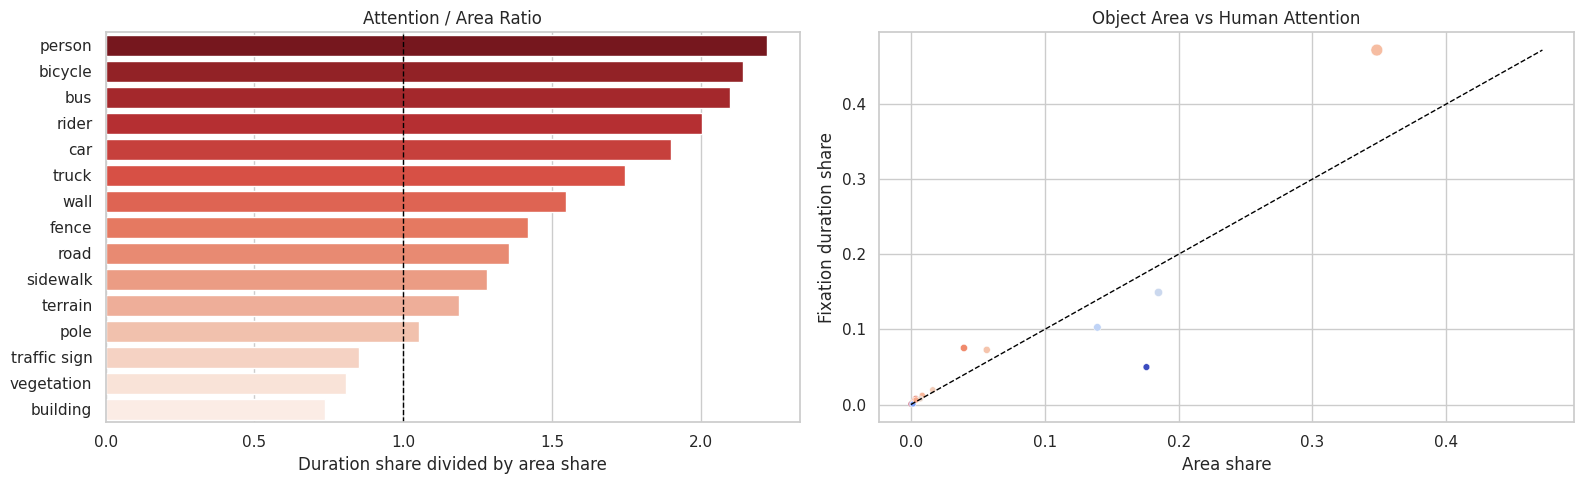

In [10]:
# Area-normalized attention: which objects get more gaze than their occupied area would predict?
object_area_attn = area_by_object.merge(
    attn_by_object[["object", "duration_share", "count_share", "fixation_duration", "fixation_count"]],
    on="object",
    how="outer",
).fillna(0)

eps = 1e-9
object_area_attn["duration_to_area_ratio"] = object_area_attn["duration_share"] / (object_area_attn["area_share"] + eps)
object_area_attn["count_to_area_ratio"] = object_area_attn["count_share"] / (object_area_attn["area_share"] + eps)
object_area_attn["log2_duration_area_enrichment"] = np.log2(object_area_attn["duration_to_area_ratio"] + eps)

# Keep a support filter for the headline plot so tiny one-off objects do not dominate.
ratio_plot = object_area_attn[
    (object_area_attn["fixation_duration"] > object_area_attn["fixation_duration"].quantile(0.10)) &
    (object_area_attn["area_share"] > 0)
].sort_values("duration_to_area_ratio", ascending=False)

display(ratio_plot.head(20))
object_area_attn.sort_values("duration_to_area_ratio", ascending=False).to_csv(
    OUT_DIR / "objects_attention_relative_to_area.csv", index=False
)

fig, ax = plt.subplots(figsize=(9, 5))
sns.barplot(data=ratio_plot.head(15), y="object", x="duration_to_area_ratio", ax=ax, palette="Reds_r")
ax.axvline(1.0, color="black", linestyle="--", linewidth=1)
ax.set_title("Attention / Area Ratio")
ax.set_xlabel("Duration share divided by area share")
ax.set_ylabel("")
plt.tight_layout()
plt.savefig(EDA_FIG_DIR / "objects_attention_area_ratio.png", dpi=220, bbox_inches="tight")
plt.show()

fig, ax = plt.subplots(figsize=(7, 5.5))
sns.scatterplot(
    data=object_area_attn,
    x="area_share",
    y="duration_share",
    size="fixation_duration",
    hue="log2_duration_area_enrichment",
    palette="coolwarm",
    ax=ax,
    legend=False,
)
lim = max(object_area_attn["area_share"].max(), object_area_attn["duration_share"].max())
ax.plot([0, lim], [0, lim], color="black", linestyle="--", linewidth=1)
ax.set_title("Object Area vs Human Attention")
ax.set_xlabel("Area share")
ax.set_ylabel("Fixation duration share")
plt.tight_layout()
plt.savefig(EDA_FIG_DIR / "objects_area_vs_attention_share.png", dpi=220, bbox_inches="tight")
plt.show()


### 3.5 Left-Right and Object Transitions

Build fixation transition records, then visualize side-to-side and object-to-object transition patterns.


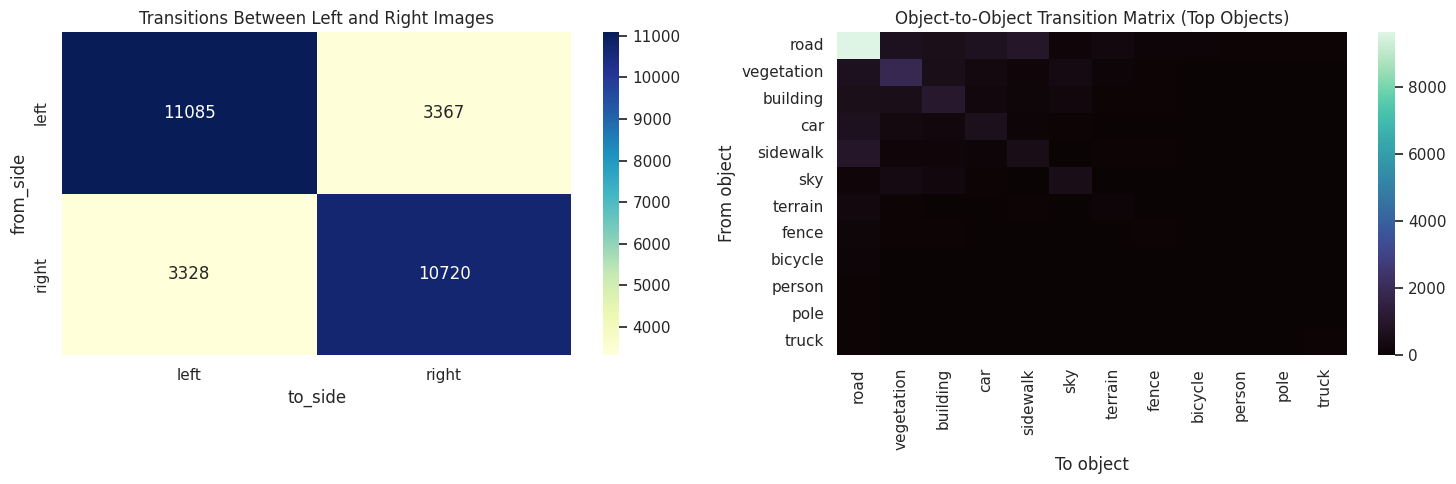

,object,cross_side_with_object,same_side_with_object,cross_side_odds_ratio,log2_cross_side_odds_ratio
5,motorcycle,14,20,2.306257,1.205553
1,building,1354,3500,1.326073,0.407160
9,road,4410,12927,1.325353,0.406377
15,train,9,24,1.263125,0.336998
0,bicycle,116,301,1.262918,0.336761
4,fence,189,496,1.250017,0.321947
6,person,111,296,1.228451,0.296840
14,traffic sign,23,64,1.187159,0.247514
12,terrain,274,760,1.182949,0.242387
3,car,934,2637,1.178798,0.237317


In [11]:
# Transitions between objects and between the left/right images.
trans_base = fix_valid.dropna(subset=["side"]).sort_values(
    ["survey_id", "trial_id", "start_time", "count_in_trial"]
).copy()

transition_rows = []
for (survey_id, trial_id), g in trans_base.groupby(["survey_id", "trial_id"]):
    g = g.reset_index(drop=True)
    for i in range(len(g) - 1):
        a = g.iloc[i]
        b = g.iloc[i + 1]
        transition_rows.append({
            "survey_id": survey_id,
            "trial_id": trial_id,
            "from_side": a["side"],
            "to_side": b["side"],
            "from_object": a["object"],
            "to_object": b["object"],
            "dt_ms": float(b["start_time"]) - float(a["start_time"]),
            "cross_side": a["side"] != b["side"],
        })

transitions = pd.DataFrame(transition_rows)
transitions.to_csv(OUT_DIR / "fixation_object_transitions.csv", index=False)

if not transitions.empty:
    side_matrix = pd.crosstab(transitions["from_side"], transitions["to_side"])
    obj_matrix = pd.crosstab(transitions["from_object"], transitions["to_object"])
    top_objs = attn_by_object.head(12)["object"].tolist()
    obj_matrix_top = obj_matrix.reindex(index=top_objs, columns=top_objs, fill_value=0)

    fig, axes = plt.subplots(1, 2, figsize=(15, 5))
    sns.heatmap(side_matrix, annot=True, fmt="d", cmap="YlGnBu", ax=axes[0])
    axes[0].set_title("Transitions Between Left and Right Images")
    sns.heatmap(obj_matrix_top, cmap="mako", ax=axes[1])
    axes[1].set_title("Object-to-Object Transition Matrix (Top Objects)")
    axes[1].set_xlabel("To object")
    axes[1].set_ylabel("From object")
    plt.tight_layout()
    plt.savefig(OUT_DIR / "transition_matrices.png", dpi=180, bbox_inches="tight")
    plt.show()

    # Association of objects with cross-image transitions.
    transition_object_rows = []
    for obj in sorted(set(transitions["from_object"]) | set(transitions["to_object"])):
        involved = (transitions["from_object"].eq(obj) | transitions["to_object"].eq(obj))
        a = int((involved & transitions["cross_side"]).sum())
        b = int((involved & ~transitions["cross_side"]).sum())
        c = int((~involved & transitions["cross_side"]).sum())
        d = int((~involved & ~transitions["cross_side"]).sum())
        odds = ((a + 0.5) * (d + 0.5)) / ((b + 0.5) * (c + 0.5))
        transition_object_rows.append({
            "object": obj,
            "cross_side_with_object": a,
            "same_side_with_object": b,
            "cross_side_odds_ratio": odds,
            "log2_cross_side_odds_ratio": np.log2(odds),
        })
    transition_object_assoc = pd.DataFrame(transition_object_rows).sort_values("cross_side_odds_ratio", ascending=False)
    display(transition_object_assoc.head(20))
    transition_object_assoc.to_csv(OUT_DIR / "objects_associated_with_left_right_transitions.csv", index=False)

### 3.6 Saccade Target Summary

Use `stats_saccades.txt` to summarize target objects, saccade counts, distance, velocity, and duration.


,object,saccade_count,mean_distance,mean_velocity,mean_duration
9,road,13525,297.863043,9.847437,54.766876
17,vegetation,4268,274.281984,7.745011,51.722352
1,building,2981,277.796781,7.781752,55.991614
3,car,2110,274.558642,9.003098,51.024645
10,sidewalk,2105,291.306882,9.329835,55.601900
11,sky,1444,255.060842,7.799697,56.332410
12,terrain,563,300.959264,6.703659,61.024867
4,fence,373,303.263782,7.967530,64.107239
0,bicycle,221,319.018769,8.042980,52.751131
6,person,219,263.624872,9.220977,45.420091


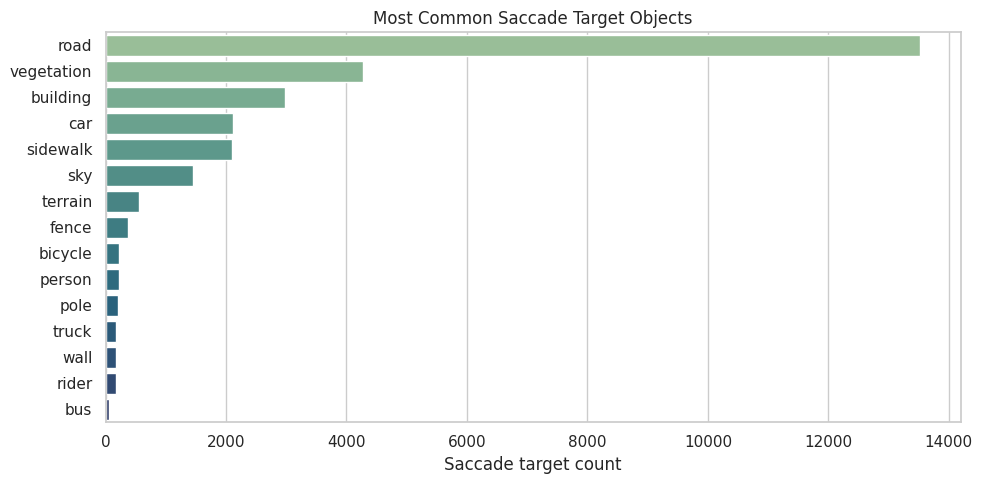

In [12]:
# Saccade target object EDA from stats_saccades.txt
def normalize_saccades(df: pd.DataFrame) -> pd.DataFrame:
    if df.empty:
        return df
    target_aoi = df.get("Saccade Target AOI", "").astype(str)
    target_group = df.get("Saccade Target AOI group", "").astype(str)
    out = pd.DataFrame({
        "survey_id": df["survey_id"].astype(str),
        "session_dir": df["session_dir"].astype(str),
        "trial_id": to_num(df.get("TrialID", -1), -1).astype(int),
        "count_in_trial": to_num(df.get("CountInTrial", -1), -1).astype(int),
        "start_time": to_num(df.get("StartTime", 0), 0).astype(float),
        "duration": to_num(df.get("Duration", 0), 0).astype(float),
        "distance": to_num(df.get("Distance", 0), 0).astype(float),
        "velocity": to_num(df.get("Velocity", 0), 0).astype(float),
        "target_aoi": target_aoi,
        "target_group": target_group,
    })
    out["side"] = out["target_aoi"].apply(infer_side_from_name)
    out["object_group"] = out["target_group"].where(out["target_group"].astype(str).str.len() > 0, out["target_aoi"])
    return out


sacc = normalize_saccades(sacc_raw)
sacc_rows = []
for _, r in sacc.iterrows():
    labels = split_object_labels(r["object_group"])
    for obj in labels:
        nr = r.to_dict()
        nr["object"] = obj
        sacc_rows.append(nr)
sacc_long = pd.DataFrame(sacc_rows) if sacc_rows else pd.DataFrame()
sacc_valid = sacc_long[~sacc_long.get("object", pd.Series(dtype=str)).isin(ignore_objects)].copy() if len(sacc_long) else sacc_long

if len(sacc_valid):
    sacc_summary = (
        sacc_valid.groupby("object", as_index=False)
        .agg(
            saccade_count=("object", "size"),
            mean_distance=("distance", "mean"),
            mean_velocity=("velocity", "mean"),
            mean_duration=("duration", "mean"),
        )
        .sort_values("saccade_count", ascending=False)
    )
    display(sacc_summary.head(20))
    sacc_summary.to_csv(OUT_DIR / "saccade_target_object_summary.csv", index=False)

    fig, ax = plt.subplots(figsize=(10, 5))
    sns.barplot(data=sacc_summary.head(15), y="object", x="saccade_count", ax=ax, palette="crest")
    ax.set_title("Most Common Saccade Target Objects")
    ax.set_xlabel("Saccade target count")
    ax.set_ylabel("")
    plt.tight_layout()
    plt.savefig(OUT_DIR / "saccade_target_objects.png", dpi=180, bbox_inches="tight")
    plt.show()

### 3.7 Standard Trial Metrics

Inspect trial-level quality and gaze-behavior metrics from `stats_standard.txt`, including data loss and fixation summaries.


,survey_id,session_dir,trial_id,Trial: Duration (ms),Trial: Data Loss (count),Trial: Data Loss (%),Gaze: Fixations (count),Gaze: Fixations (count/s),Gaze: Fixations Until First Click (count),Gaze: Fixation Duration Mean (ms),Gaze: Fixation Duration Median (ms),Gaze: Fixation/Saccade ratio,Gaze: Average Saccade Length (px)
0,cycling08ab6849b6ce9851d50c230e82c8b2ba0564ffc...,cycling08ab6849b6ce9851d50c230e82c8b2ba0564ffc...,1,4323.0,0.0,0.0,15.0,3.469813,-1.0,170.266667,177.0,590.793430,440.5640
1,cycling08ab6849b6ce9851d50c230e82c8b2ba0564ffc...,cycling08ab6849b6ce9851d50c230e82c8b2ba0564ffc...,2,10028.0,0.0,0.0,28.0,2.792182,-1.0,282.964286,257.0,790.087754,311.4670
2,cycling08ab6849b6ce9851d50c230e82c8b2ba0564ffc...,cycling08ab6849b6ce9851d50c230e82c8b2ba0564ffc...,3,8651.0,0.0,0.0,29.0,3.352214,-1.0,242.413793,245.0,812.622818,228.7916
3,cycling08ab6849b6ce9851d50c230e82c8b2ba0564ffc...,cycling08ab6849b6ce9851d50c230e82c8b2ba0564ffc...,4,7416.0,0.0,0.0,26.0,3.505933,-1.0,215.538462,210.0,755.663430,325.6483
4,cycling08ab6849b6ce9851d50c230e82c8b2ba0564ffc...,cycling08ab6849b6ce9851d50c230e82c8b2ba0564ffc...,5,7445.0,0.0,0.0,20.0,2.686367,-1.0,320.900000,256.5,862.055071,373.4564


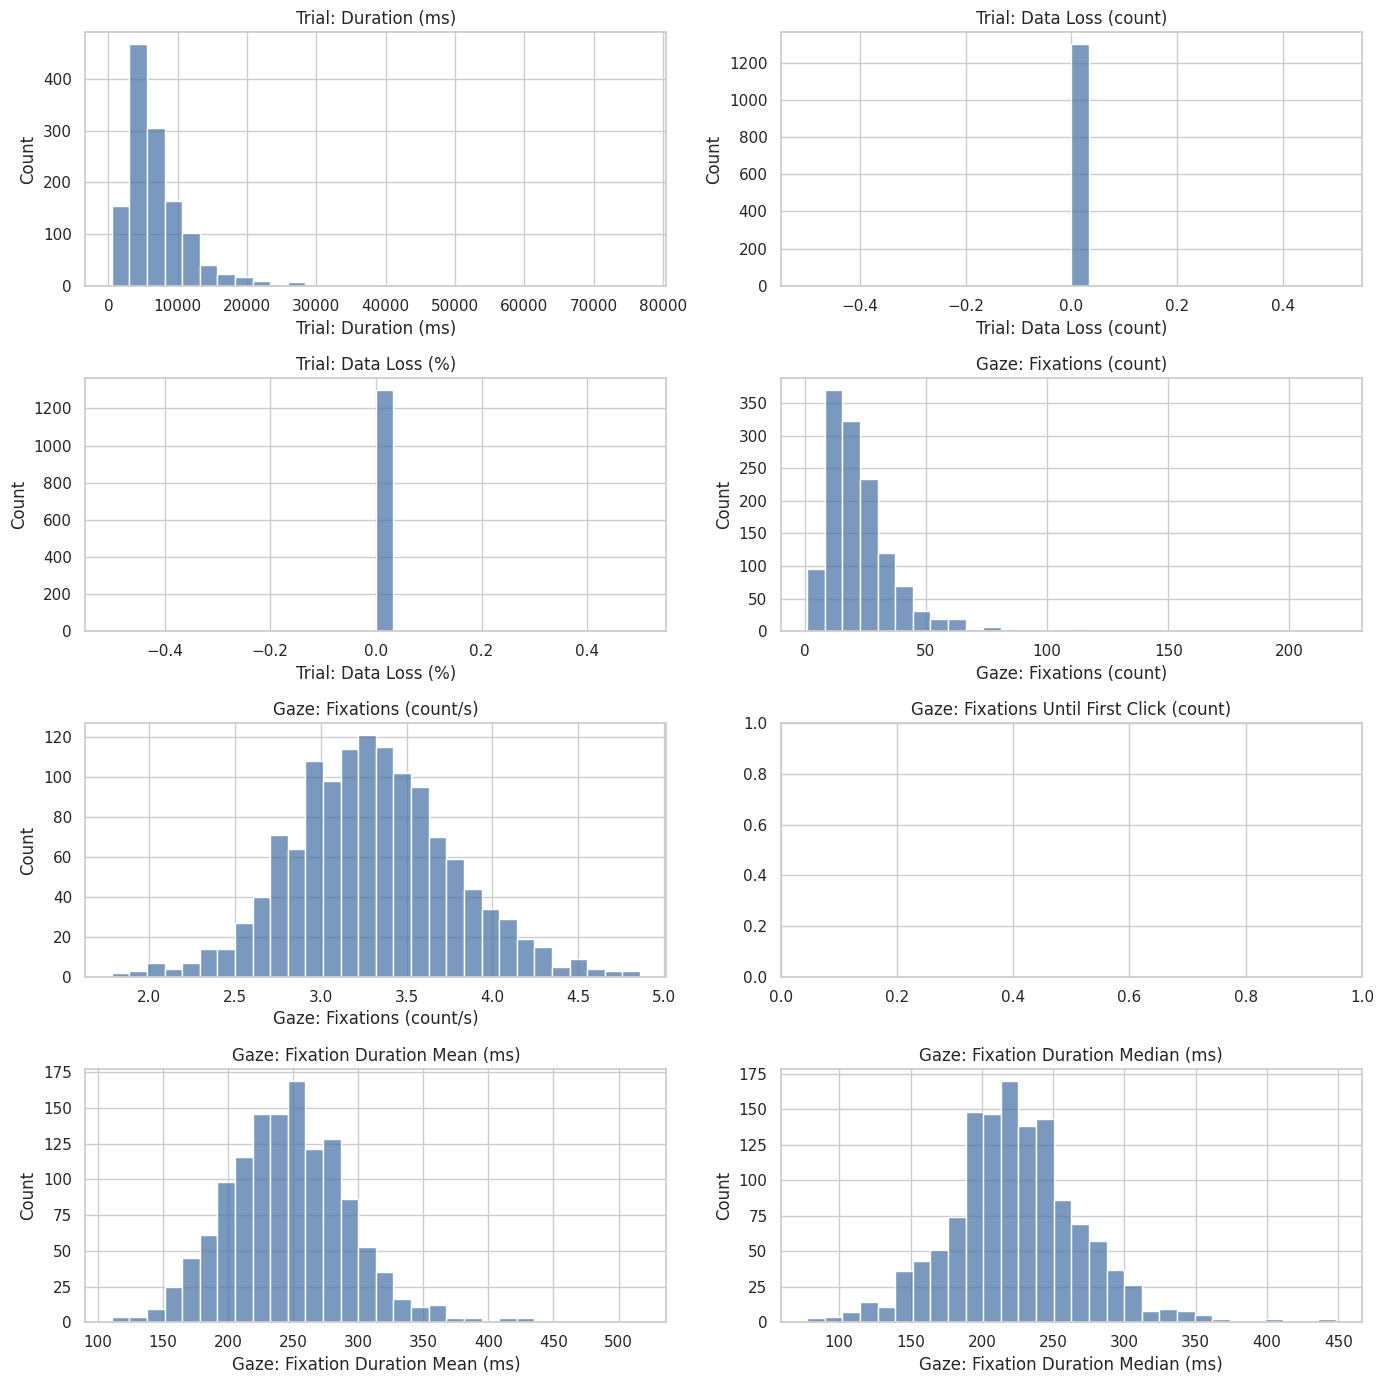

In [13]:
# Trial-level eye-tracking quality/standard metrics from stats_standard.txt
if not standard_raw.empty:
    standard = standard_raw.copy()
    standard["survey_id"] = standard["survey_id"].astype(str)
    trial_col = "Trial: ID" if "Trial: ID" in standard.columns else None
    if trial_col:
        standard["trial_id"] = to_num(standard[trial_col], -1).astype(int)
    numeric_cols = []
    for c in standard.columns:
        vals = pd.to_numeric(standard[c], errors="coerce")
        if vals.notna().sum() >= max(5, len(standard) * 0.2):
            standard[c] = vals
            numeric_cols.append(c)

    quality_cols = [
        c for c in numeric_cols
        if any(k in c.lower() for k in ["fixation", "saccade", "data loss", "duration", "velocity"])
    ]
    display(standard[["survey_id", "session_dir"] + (["trial_id"] if "trial_id" in standard.columns else []) + quality_cols[:10]].head())
    standard.describe(include="all").to_csv(OUT_DIR / "stats_standard_describe.csv")

    plot_cols = quality_cols[:8]
    if plot_cols:
        fig, axes = plt.subplots(math.ceil(len(plot_cols) / 2), 2, figsize=(14, 3.5 * math.ceil(len(plot_cols) / 2)))
        axes = np.array(axes).reshape(-1)
        for ax, c in zip(axes, plot_cols):
            sns.histplot(standard[c].replace([-1, -2], np.nan).dropna(), bins=30, ax=ax, color="#4C78A8")
            ax.set_title(c)
        for ax in axes[len(plot_cols):]:
            ax.axis("off")
        plt.tight_layout()
        plt.savefig(OUT_DIR / "stats_standard_histograms.png", dpi=180, bbox_inches="tight")
        plt.show()

## 4. Safer vs Unsafe Perception by Object

### 4.1 Object Associations With Safety Labels
Connect object presence and attention with the safest/unsafest side of each trial. The first table reports the proportion of image sides judged safest or unsafest when each object is present; the second table asks the same question weighted by observed fixation duration.


safety_label,object,safer,unsafe,tie,image_sides_with_object,proportion_safest_when_object_present,proportion_unsafest_when_object_present
16,truck,28,14,0,42,0.666667,0.333333
2,bus,18,12,0,30,0.600000,0.400000
15,train,6,4,0,10,0.600000,0.400000
3,car,176,165,0,341,0.516129,0.483871
14,traffic sign,73,71,0,144,0.506944,0.493056
17,vegetation,183,180,0,363,0.504132,0.495868
1,building,184,182,0,366,0.502732,0.497268
10,sidewalk,183,182,0,365,0.501370,0.498630
11,sky,186,185,0,371,0.501348,0.498652
9,road,188,188,0,376,0.500000,0.500000


safety_label,object,safer,unsafe,tie,safer_minus_unsafe_attention,safer_attention_share,unsafe_attention_share
0,car,38523.0,19266.0,0.0,19257.0,0.666615,0.333385
1,building,53930.0,46059.0,0.0,7871.0,0.539359,0.460641
2,sky,24775.0,21747.0,0.0,3028.0,0.532544,0.467456
3,truck,3143.0,590.0,0.0,2553.0,0.841950,0.158050
4,vegetation,68537.0,67899.0,0.0,638.0,0.502338,0.497662
5,person,3366.0,2787.0,0.0,579.0,0.547050,0.452950
6,train,429.0,0.0,0.0,429.0,1.000000,0.000000
7,traffic sign,1297.0,1010.0,0.0,287.0,0.562202,0.437798
8,motorcycle,278.0,0.0,0.0,278.0,1.000000,0.000000
9,rider,2910.0,2858.0,0.0,52.0,0.504508,0.495492


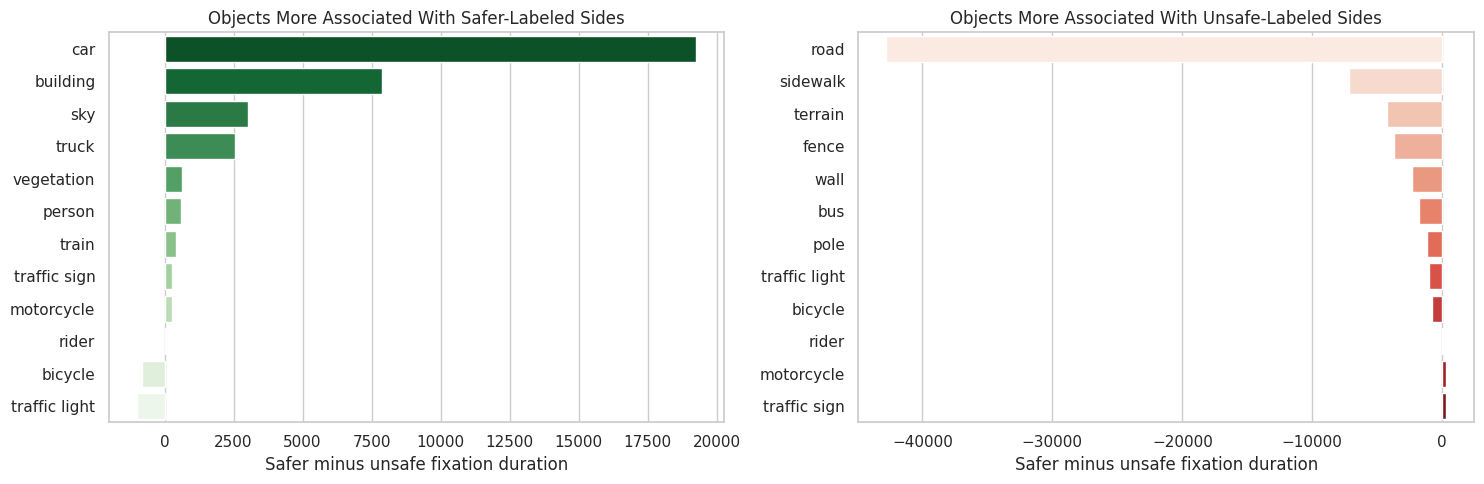

In [14]:
df_test = pd.read_pickle(TEST_PKL).copy()
df_test["survey_id"] = df_test["survey_id"].astype(str)
df_test["trial_id"] = df_test["trial_id"].astype(int)
df_test["score"] = pd.to_numeric(df_test["score"], errors="coerce")

def side_label_from_score(score: float, side: str) -> str:
    # Pairwise ranking convention used by the project: positive score favors left, negative favors right, zero is tie.
    if pd.isna(score) or score == 0:
        return "tie"
    if side == "left":
        return "safer" if score > 0 else "unsafe"
    return "safer" if score < 0 else "unsafe"


side_rows = []
for _, r in df_test.iterrows():
    for side in ["left", "right"]:
        side_rows.append({
            "survey_id": r["survey_id"],
            "trial_id": int(r["trial_id"]),
            "side": side,
            "image": r["image_l"] if side == "left" else r["image_r"],
            "score": float(r["score"]) if pd.notna(r["score"]) else np.nan,
            "safety_label": side_label_from_score(r["score"], side),
            "has_eyetracker": bool(r.get("has_eyetracker", False)),
        })
trial_sides = pd.DataFrame(side_rows)

fix_trial_obj = (
    fix_valid.groupby(["survey_id", "trial_id", "side", "object"], as_index=False)
    .agg(fixation_duration=("duration_weighted", "sum"), fixation_count=("count_weighted", "sum"))
)

aoi_trial_obj = (
    aoi_valid.groupby(["survey_id", "trial_id", "side", "object"], as_index=False)
    .agg(area_px=("area_px", "sum"))
)

presence_obj = trial_sides.merge(aoi_trial_obj, on=["survey_id", "trial_id", "side"], how="inner")
presence_obj = presence_obj[
    (presence_obj["area_px"].fillna(0) > 0) &
    (~presence_obj["object"].fillna("unknown").isin(ignore_objects))
].copy()

presence_counts = (
    presence_obj.groupby(["object", "safety_label"], as_index=False)
    .size()
    .rename(columns={"size": "image_sides"})
)
presence_pivot = presence_counts.pivot(index="object", columns="safety_label", values="image_sides").fillna(0)
for col in ["safer", "unsafe", "tie"]:
    if col not in presence_pivot.columns:
        presence_pivot[col] = 0
presence_pivot["image_sides_with_object"] = presence_pivot[["safer", "unsafe", "tie"]].sum(axis=1)
presence_pivot["proportion_safest_when_object_present"] = presence_pivot["safer"] / (presence_pivot["image_sides_with_object"] + 1e-9)
presence_pivot["proportion_unsafest_when_object_present"] = presence_pivot["unsafe"] / (presence_pivot["image_sides_with_object"] + 1e-9)
presence_pivot = (
    presence_pivot.reset_index()
    .sort_values(["proportion_safest_when_object_present", "image_sides_with_object"], ascending=[False, False])
)
presence_pivot.to_csv(OUT_DIR / "object_presence_safest_unsafest_proportions.csv", index=False)
display(presence_pivot.head(25))

obj_safety = trial_sides.merge(fix_trial_obj, on=["survey_id", "trial_id", "side"], how="left")
obj_safety = obj_safety.merge(aoi_trial_obj, on=["survey_id", "trial_id", "side", "object"], how="outer")
obj_safety["fixation_duration"] = obj_safety["fixation_duration"].fillna(0.0)
obj_safety["fixation_count"] = obj_safety["fixation_count"].fillna(0.0)
obj_safety["area_px"] = obj_safety["area_px"].fillna(0.0)
obj_safety = obj_safety[~obj_safety["object"].fillna("unknown").isin(ignore_objects)].copy()

safety_summary = (
    obj_safety.groupby(["object", "safety_label"], as_index=False)
    .agg(
        attention_duration=("fixation_duration", "sum"),
        fixation_count=("fixation_count", "sum"),
        area_px=("area_px", "sum"),
        n_sides=("side", "size"),
    )
)

pivot = safety_summary.pivot_table(index="object", columns="safety_label", values="attention_duration", aggfunc="sum", fill_value=0)
for col in ["safer", "unsafe", "tie"]:
    if col not in pivot.columns:
        pivot[col] = 0.0
pivot["safer_minus_unsafe_attention"] = pivot["safer"] - pivot["unsafe"]
pivot["safer_attention_share"] = pivot["safer"] / (pivot["safer"] + pivot["unsafe"] + 1e-9)
pivot["unsafe_attention_share"] = pivot["unsafe"] / (pivot["safer"] + pivot["unsafe"] + 1e-9)
pivot = pivot.sort_values("safer_minus_unsafe_attention", ascending=False).reset_index()

display(pivot)
pivot.to_csv(OUT_DIR / "objects_safer_vs_unsafe_attention.csv", index=False)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
safe_top = pivot.sort_values("safer_minus_unsafe_attention", ascending=False).head(12)
unsafe_top = pivot.sort_values("safer_minus_unsafe_attention", ascending=True).head(12)
sns.barplot(data=safe_top, y="object", x="safer_minus_unsafe_attention", ax=axes[0], palette="Greens_r")
axes[0].set_title("Objects More Associated With Safer-Labeled Sides")
axes[0].set_xlabel("Safer minus unsafe fixation duration")
axes[0].set_ylabel("")
sns.barplot(data=unsafe_top, y="object", x="safer_minus_unsafe_attention", ax=axes[1], palette="Reds")
axes[1].set_title("Objects More Associated With Unsafe-Labeled Sides")
axes[1].set_xlabel("Safer minus unsafe fixation duration")
axes[1].set_ylabel("")
plt.tight_layout()
plt.savefig(OUT_DIR / "objects_safer_unsafe_association.png", dpi=180, bbox_inches="tight")
plt.show()


## 5. Model-Human Alignment: Ranking-Branch VGG Grad-CAM vs Human Gaze

### 5.1 Grad-CAM Evaluation Setup

Configure device, transforms, test eye-tracker rows, dataset, dataloader, checkpoint path, and requested metric list.


In [15]:
# Imports for the model-alignment section
import sys
import torch
import torch.nn.functional as F
from torch.utils.data import DataLoader
from sklearn.metrics import roc_auc_score
from scipy.stats import wasserstein_distance
import torchvision.models as tv_models

if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from data import ComparisonsDataset, build_eval_transforms
from nets.cnn import CNN

GPU_ID = 0
DEVICE = torch.device(f"cuda:{GPU_ID}" if torch.cuda.is_available() and torch.cuda.device_count() > GPU_ID else "cpu")
print("DEVICE:", DEVICE)
if DEVICE.type == "cuda":
    print("GPU:", torch.cuda.get_device_name(DEVICE))

BACKBONE_NAME = "vgg19"
MODEL_TYPE = "rsscnn"
GAZE_GRID = (14, 14)
BATCH_SIZE = 8
NUM_WORKERS = 2
COMPUTE_sAUC = True
sAUC_NEG_SAMPLES = 1000

METRICS = ["KL", "CC", "SIM", "NSS", "AUC", "sAUC", "EMD", "IG"]

SPECS = {
    "input_size": (3, 224, 224),
    "crop_pct": 0.875,
    "mean": (0.485, 0.456, 0.406),
    "std": (0.229, 0.224, 0.225),
    "interpolation": "bilinear",
}

eval_tfms, eval_meta = build_eval_transforms(
    SPECS,
    gaze_grid_size=GAZE_GRID,
    enable_gaze=True,
    gaze_output="align",
)

df_gradcam = df_test[df_test["has_eyetracker"].astype(bool)].copy().reset_index(drop=True)
print("Grad-CAM rows with eyetracker:", len(df_gradcam))

ds = ComparisonsDataset(
    dataframe=df_gradcam,
    root_dir=str(DATASET_ROOT),
    transform=eval_tfms,
    gaze_root=str(GAZE_ROOT_864),
    use_gaze=True,
    use_seg=False,
)

loader = DataLoader(
    ds,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=(DEVICE.type == "cuda"),
)

print("Dataset:", len(ds), "batches:", math.ceil(len(ds) / BATCH_SIZE))

/home/csantiago/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


DEVICE: cuda:0
GPU: NVIDIA GeForce GTX 1080 Ti
Grad-CAM rows with eyetracker: 186
Dataset: 186 batches: 24


### 5.2 Load VGG Ranking Model

Rebuild the RSSCNN/VGG model from `models/vgg_syn+ber.pt` by inferring checkpoint head dimensions and loading weights.


In [16]:
def _strip_module_prefix(state_dict: dict) -> dict:
    return {k[7:] if k.startswith("module.") else k: v for k, v in state_dict.items()}


def _extract_state_dict(ckpt_obj) -> dict:
    if isinstance(ckpt_obj, dict) and "model" in ckpt_obj and isinstance(ckpt_obj["model"], dict):
        return ckpt_obj["model"]
    if isinstance(ckpt_obj, dict) and "state_dict" in ckpt_obj and isinstance(ckpt_obj["state_dict"], dict):
        return ckpt_obj["state_dict"]
    if isinstance(ckpt_obj, dict) and all(isinstance(k, str) for k in ckpt_obj.keys()):
        return ckpt_obj
    raise ValueError(f"Unrecognized checkpoint format: {type(ckpt_obj)}")


def load_state_dict_from_path(ckpt_path: Path) -> dict:
    ckpt = torch.load(str(ckpt_path), map_location="cpu")
    return _strip_module_prefix(_extract_state_dict(ckpt))


def make_backbone_factory(name: str):
    fn = getattr(tv_models, name)

    def build(weights=None):
        # The project checkpoint already stores the trained weights; avoid downloading ImageNet weights.
        try:
            return fn(weights=None)
        except TypeError:
            return fn(pretrained=False)
    return build


def build_cnn_model_for_checkpoint(ckpt_path: Path, backbone_name: str = "vgg19", model_type: str = "rsscnn"):
    sd = load_state_dict_from_path(ckpt_path)
    flat_dim_override = int(sd["rank_fc_1.weight"].shape[1])
    num_classes = int(sd["cross_fc_3.weight"].shape[0])
    net = CNN(
        backbone=make_backbone_factory(backbone_name),
        model=model_type,
        finetune=True,
        num_classes=num_classes,
        flat_dim_override=flat_dim_override,
        flatten_spatial=(flat_dim_override > 1024),
        gaze_grid_size=int(GAZE_GRID[0]),
    )
    missing, unexpected = net.load_state_dict(sd, strict=False)
    print("missing keys:", len(missing), "unexpected keys:", len(unexpected))
    net.to(DEVICE).eval()
    return net


net = build_cnn_model_for_checkpoint(CHECKPOINT, BACKBONE_NAME, MODEL_TYPE)
print("Model loaded:", CHECKPOINT)

missing keys: 0 unexpected keys: 0
Model loaded: /home/csantiago/models/vgg_syn+ber.pt


### 5.3 Saliency Metrics and Grad-CAM

Define the saliency metrics and the ranking-branch Grad-CAM function used for model-human alignment.


In [17]:
EPS = 1e-12


def to_numpy_2d(x) -> np.ndarray:
    if not torch.is_tensor(x):
        x = torch.as_tensor(x)
    x = x.detach().cpu().float()
    if x.ndim == 4:
        x = x[0, 0]
    elif x.ndim == 3:
        x = x[0]
    return x.numpy().astype(np.float64)


def normalize_prob(m: np.ndarray) -> np.ndarray:
    m = np.asarray(m, dtype=np.float64)
    m = np.maximum(m, 0.0)
    s = float(m.sum())
    if not np.isfinite(s) or s <= 0:
        u = np.ones_like(m, dtype=np.float64)
        return u / (u.sum() + EPS)
    return m / (s + EPS)


def zscore(m: np.ndarray) -> np.ndarray:
    m = np.asarray(m, dtype=np.float64)
    sd = float(m.std())
    return (m - float(m.mean())) / (sd + EPS)


def fixation_from_gaze(gaze_prob: np.ndarray, topk: int = 20) -> np.ndarray:
    g = normalize_prob(gaze_prob)
    h, w = g.shape
    k = max(1, min(int(topk), h * w))
    flat = g.reshape(-1)
    idx = np.argpartition(flat, -k)[-k:]
    fix = np.zeros_like(flat, dtype=np.uint8)
    fix[idx] = 1
    return fix.reshape(h, w)


def metric_KL(gt, pred):
    p = normalize_prob(gt)
    q = normalize_prob(pred)
    return float(np.sum(p * (np.log(p + EPS) - np.log(q + EPS))))


def metric_CC(gt, pred):
    g = np.asarray(gt).reshape(-1).astype(np.float64)
    s = np.asarray(pred).reshape(-1).astype(np.float64)
    g = g - g.mean()
    s = s - s.mean()
    return float(np.dot(g, s) / ((np.linalg.norm(g) * np.linalg.norm(s)) + EPS))


def metric_SIM(gt, pred):
    p = normalize_prob(gt)
    q = normalize_prob(pred)
    return float(np.minimum(p, q).sum())


def metric_NSS(gt, pred):
    fix = fixation_from_gaze(gt).astype(bool)
    s = zscore(pred)
    return float(s[fix].mean()) if fix.sum() else float("nan")


def metric_AUC(gt, pred):
    fix = fixation_from_gaze(gt).reshape(-1).astype(np.uint8)
    scores = np.asarray(pred).reshape(-1).astype(np.float64)
    if len(np.unique(fix)) < 2:
        return float("nan")
    return float(roc_auc_score(fix, scores))


def metric_sAUC(gt, pred, other_fix_pool, neg_samples=1000):
    fix = fixation_from_gaze(gt).astype(bool)
    pos = np.asarray(pred)[fix]
    if pos.size == 0 or other_fix_pool is None or len(other_fix_pool) == 0:
        return float("nan")
    h, w = pred.shape
    idx = np.random.choice(len(other_fix_pool), size=min(int(neg_samples), len(other_fix_pool)), replace=False)
    neg_coords = other_fix_pool[idx]
    neg = np.asarray(pred)[np.clip(neg_coords[:, 0], 0, h - 1), np.clip(neg_coords[:, 1], 0, w - 1)]
    y = np.r_[np.ones_like(pos), np.zeros_like(neg)]
    s = np.r_[pos, neg]
    if len(np.unique(y)) < 2:
        return float("nan")
    return float(roc_auc_score(y, s))


def metric_EMD(gt, pred):
    p = normalize_prob(gt)
    q = normalize_prob(pred)
    h, w = p.shape
    ys = np.arange(h)
    xs = np.arange(w)
    emd_y = wasserstein_distance(ys, ys, u_weights=p.sum(axis=1), v_weights=q.sum(axis=1))
    emd_x = wasserstein_distance(xs, xs, u_weights=p.sum(axis=0), v_weights=q.sum(axis=0))
    return float(emd_x + emd_y)


def metric_IG(gt, pred, baseline):
    fix = fixation_from_gaze(gt).astype(bool)
    p = normalize_prob(pred)
    b = normalize_prob(baseline)
    if fix.sum() == 0:
        return float("nan")
    return float(np.mean(np.log2(p[fix] + EPS) - np.log2(b[fix] + EPS)))


def gradcam_ranking(net: CNN, x: torch.Tensor, out_hw=(14, 14)) -> torch.Tensor:
    net.eval()
    x = x.detach().clone().requires_grad_(True)
    feat_map, flat = net._forward_backbone(x)
    feat_map.retain_grad()

    z = net.rank_fc_1(flat)
    z = net.rank_relu(z)
    z = net.rank_drop(z)
    score = net.rank_fc_out(z)

    net.zero_grad(set_to_none=True)
    score.sum().backward()

    grads = feat_map.grad
    weights = grads.mean(dim=(2, 3), keepdim=True)
    cam = F.relu((weights * feat_map).sum(dim=1, keepdim=True))
    cam = F.interpolate(cam, size=out_hw, mode="bilinear", align_corners=False).squeeze(1)
    flat = cam.flatten(1).clamp(min=1e-8)
    flat = flat / flat.sum(dim=1, keepdim=True).clamp(min=1e-8)
    return flat.view(cam.shape[0], out_hw[0], out_hw[1]).detach()

### 5.4 Run Alignment Evaluation

Compute per-image Grad-CAM vs human gaze metrics, summarize the results, and save summary/per-image CSV files.


In [18]:
@torch.no_grad()
def collect_other_fixations(loader: DataLoader) -> np.ndarray:
    coords = []
    for batch in loader:
        has_eye = batch["has_eyetracker"].bool()
        for i in range(batch["image_l"].shape[0]):
            if not bool(has_eye[i]):
                continue
            for side in ("l", "r"):
                g = to_numpy_2d(batch[f"gaze_{side}"][i])
                c = np.argwhere(fixation_from_gaze(g).astype(bool))
                if c.size:
                    coords.append(c)
    return np.concatenate(coords, axis=0).astype(np.int64) if coords else np.zeros((0, 2), dtype=np.int64)


@torch.no_grad()
def collect_baseline_gaze(loader: DataLoader) -> np.ndarray:
    maps = []
    for batch in loader:
        has_eye = batch["has_eyetracker"].bool()
        for i in range(batch["image_l"].shape[0]):
            if not bool(has_eye[i]):
                continue
            maps.append(normalize_prob(to_numpy_2d(batch["gaze_l"][i])))
            maps.append(normalize_prob(to_numpy_2d(batch["gaze_r"][i])))
    return normalize_prob(np.mean(maps, axis=0)) if maps else np.ones(GAZE_GRID, dtype=np.float64) / np.prod(GAZE_GRID)


def evaluate_gradcam_alignment(net: CNN, loader: DataLoader, device: torch.device) -> tuple[pd.DataFrame, pd.DataFrame]:
    baseline = collect_baseline_gaze(loader)
    other_fix = collect_other_fixations(loader) if COMPUTE_sAUC else None
    rows = []
    global_idx = 0

    for batch in loader:
        x_l = batch["image_l"].to(device, non_blocking=True)
        x_r = batch["image_r"].to(device, non_blocking=True)
        has_eye = batch["has_eyetracker"].bool()
        gaze_l = batch["gaze_l"]
        gaze_r = batch["gaze_r"]

        with torch.enable_grad():
            cam_l = gradcam_ranking(net, x_l, out_hw=GAZE_GRID)
            cam_r = gradcam_ranking(net, x_r, out_hw=GAZE_GRID)

        for i in range(x_l.shape[0]):
            if not bool(has_eye[i]):
                continue
            row_meta = df_gradcam.iloc[global_idx + i]
            for side, cam_t, gaze_t in (("left", cam_l[i], gaze_l[i]), ("right", cam_r[i], gaze_r[i])):
                pred = to_numpy_2d(cam_t)
                gt = to_numpy_2d(gaze_t)
                rec = {
                    "ds_idx": int(global_idx + i),
                    "survey_id": row_meta["survey_id"],
                    "trial_id": int(row_meta["trial_id"]),
                    "side": side,
                    "image": row_meta["image_l"] if side == "left" else row_meta["image_r"],
                    "KL": metric_KL(gt, pred),
                    "CC": metric_CC(gt, pred),
                    "SIM": metric_SIM(gt, pred),
                    "NSS": metric_NSS(gt, pred),
                    "AUC": metric_AUC(gt, pred),
                    "EMD": metric_EMD(gt, pred),
                    "IG": metric_IG(gt, pred, baseline),
                }
                rec["sAUC"] = metric_sAUC(gt, pred, other_fix, sAUC_NEG_SAMPLES) if COMPUTE_sAUC else np.nan
                rows.append(rec)
        global_idx += x_l.shape[0]

    per_image = pd.DataFrame(rows)
    summary = per_image[METRICS].agg(["mean", "std", "min", "max", "count"]).T
    return summary, per_image


gradcam_summary, gradcam_per_image = evaluate_gradcam_alignment(net, loader, DEVICE)
display(gradcam_summary)
display(gradcam_per_image.head())

gradcam_summary.to_csv(OUT_DIR / "gradcam_human_alignment_summary.csv")
gradcam_per_image.to_csv(OUT_DIR / "gradcam_human_alignment_per_image.csv", index=False)

,mean,std,min,max,count
KL,7.344354,3.783489,0.792796,14.901814,324.0
CC,-0.041531,0.216320,-0.387996,0.766916,324.0
SIM,0.162151,0.127012,0.000005,0.596105,324.0
NSS,-0.106353,0.561568,-0.942560,2.040132,324.0
AUC,0.468302,0.177599,0.127131,0.959943,324.0
sAUC,0.489386,0.146951,0.137275,0.940725,324.0
EMD,6.107852,2.158851,1.422316,13.131784,324.0
IG,-9.164393,5.578638,-20.220319,2.586816,324.0


,ds_idx,survey_id,trial_id,side,image,KL,CC,SIM,NSS,AUC,EMD,IG,sAUC
0,1,cycling0a3df224a10f3472c2a9c568a927406a49b0121...,59,left,3116.jpg,1.062931,0.533831,0.381052,1.741321,0.930682,4.097982,0.603711,0.844475
1,1,cycling0a3df224a10f3472c2a9c568a927406a49b0121...,59,right,6434.jpg,7.176239,-0.022974,0.109168,-0.065968,0.568182,8.005109,-9.516095,0.588300
2,3,cycling08ab6849b6ce9851d50c230e82c8b2ba0564ffc...,50,left,1999.jpg,1.058177,0.520874,0.395949,1.591068,0.918182,2.597613,-0.025302,0.709500
3,3,cycling08ab6849b6ce9851d50c230e82c8b2ba0564ffc...,50,right,10067.jpg,3.176649,0.244323,0.358767,0.620355,0.729688,3.302832,-1.432823,0.492625
4,5,cycling684fdee4e2ba556e4e23a3f68062835cf9796ce...,20,left,1276.jpg,13.327097,-0.163252,0.025692,-0.528952,0.276278,9.491361,-17.542874,0.450850


## 6. Visual Sanity Checks

### 6.1 Random Grad-CAM and Gaze View
Draw one random test image using the original image file for visual clarity, then overlay the model Grad-CAM and human gaze map after resizing each saliency map to the original image dimensions.


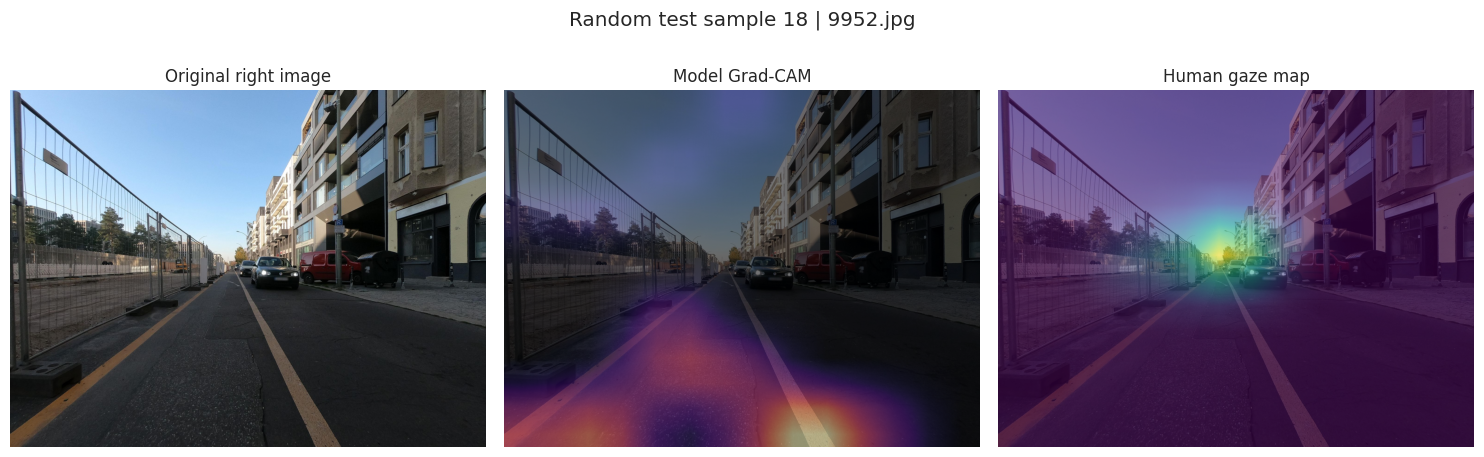

In [26]:
SEED = 66
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)


def upsample_map(sal_map, target_hw):
    if torch.is_tensor(sal_map):
        sal_map = sal_map.detach().cpu().float().numpy()
    arr = np.asarray(sal_map, dtype=np.float32)
    arr = np.nan_to_num(arr, nan=0.0, posinf=0.0, neginf=0.0)
    if arr.max() > arr.min():
        arr = (arr - arr.min()) / (arr.max() - arr.min())
    h, w = target_hw
    return np.asarray(Image.fromarray((arr * 255).astype(np.uint8)).resize((w, h), Image.Resampling.BILINEAR)) / 255.0


def original_image_path(row, side):
    image_col = "image_l" if side == "left" else "image_r"
    dataset = row.get("dataset", "")
    image_name = row.get(image_col)
    candidates = []
    if pd.notna(dataset) and str(dataset):
        candidates.append(DATASET_ROOT / str(dataset) / str(image_name))
    candidates.append(DATASET_ROOT / str(image_name))
    for path in candidates:
        if path.exists():
            return path
    return candidates[0]


def visualize_random_gradcam(idx=None, side=None):
    required = ["net", "ds", "df_gradcam", "gradcam_ranking", "DEVICE"]
    missing = [name for name in required if name not in globals()]
    if missing:
        print("Missing objects for Grad-CAM visualization:", missing)
        print("Run sections 5.1 to 5.3 first, especially the model-loading cell that creates `net`.")
        return
    if len(ds) == 0:
        print("Dataset is empty; no image is available for Grad-CAM visualization.")
        return
    if idx is None:
        idx = random.randrange(len(ds))
    sample = ds[idx]
    row = df_gradcam.iloc[idx]
    if side is None:
        side = random.choice(["left", "right"])

    img_t = sample["image_l" if side == "left" else "image_r"].unsqueeze(0).to(DEVICE)
    gaze_t = sample["gaze_l" if side == "left" else "gaze_r"].squeeze().detach().cpu().numpy()

    cam = gradcam_ranking(net, img_t, out_hw=GAZE_GRID)[0]
    img_path = original_image_path(row, side)
    original_img = np.asarray(Image.open(img_path).convert("RGB"), dtype=np.float32) / 255.0
    h, w = original_img.shape[:2]
    cam_img = upsample_map(cam, (h, w))
    gaze_img = upsample_map(gaze_t, (h, w))

    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    axes[0].imshow(original_img)
    axes[0].set_title(f"Original {side} image")
    axes[1].imshow(original_img)
    axes[1].imshow(cam_img, cmap="magma", alpha=0.55)
    axes[1].set_title("Model Grad-CAM")
    axes[2].imshow(original_img)
    axes[2].imshow(gaze_img, cmap="viridis", alpha=0.55)
    axes[2].set_title("Human gaze map")
    for ax in axes:
        ax.axis("off")
    fig.suptitle(f"Random test sample {idx} | {img_path.name}")
    plt.tight_layout()
    fig.savefig(OUT_DIR / "random_gradcam_gaze_overlay.png", dpi=160, bbox_inches="tight")
    plt.show()

visualize_random_gradcam()


### 6.2 Random AOI Outline View

Draw AOI object outlines from `aoi.txt` on a random trial screenshot, then place each object name near the middle of its largest polygon for visual inspection of the annotations.


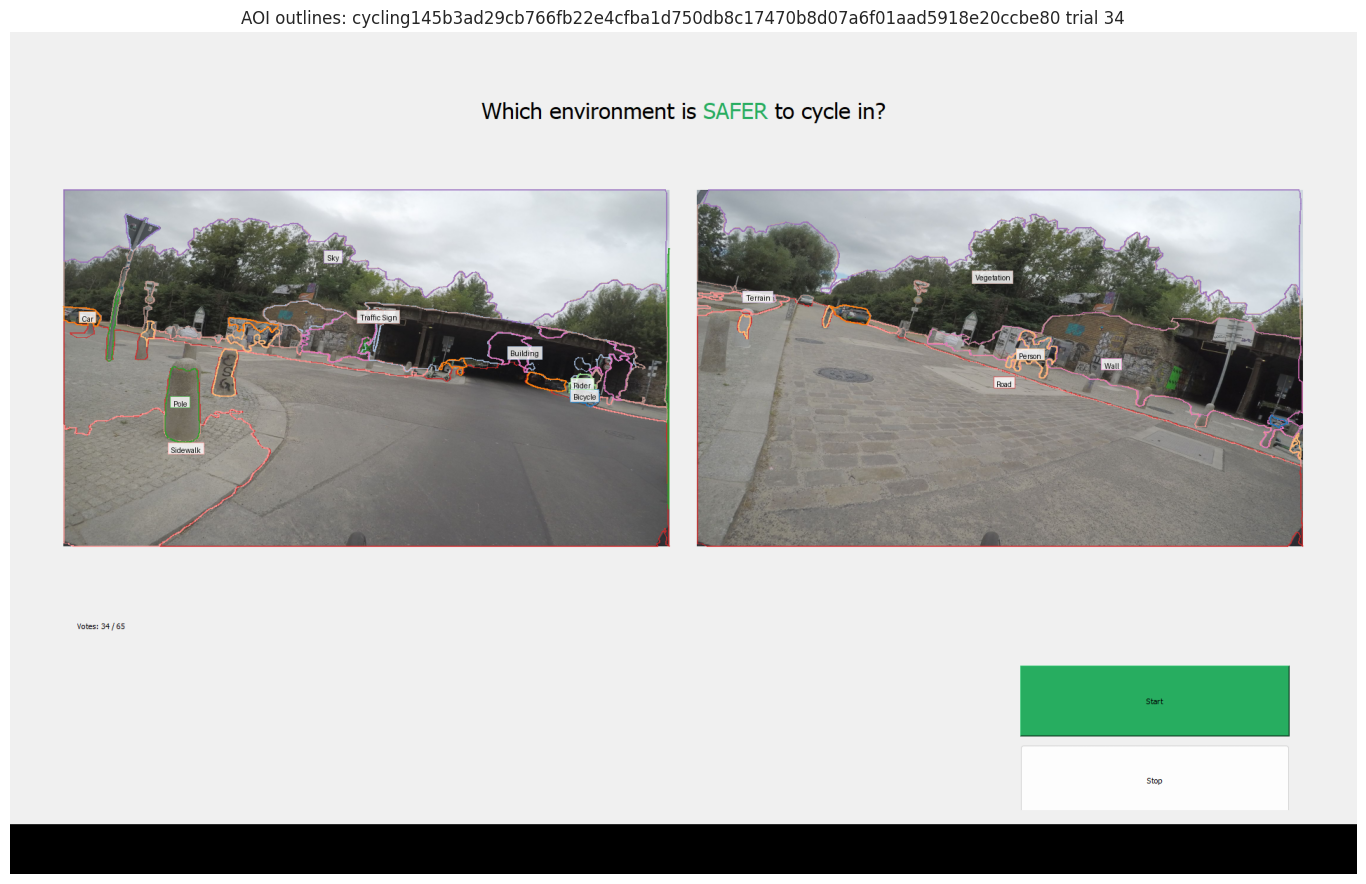

Screenshot: /home/csantiago/survey_eye_tracker/eye_tracker_data/cycling145b3ad29cb766fb22e4cfba1d750db8c17470b8d07a6f01aad5918e20ccbe80/2022_11_29_09_51_39/34-sequences;si_1500_3-sequences;si_1500_4.png


,object,area_px,shapes
6,road,383198.0,3
8,sky,166281.0,2
11,vegetation,153280.0,7
7,sidewalk,63787.0,6
12,wall,53022.5,8
1,building,25477.0,4
4,pole,6155.0,3
3,person,6106.0,7
2,car,3886.5,5
0,bicycle,983.0,2


In [24]:
def trial_screenshot(session: Path, trial_id: int) -> Path | None:
    matches = sorted(session.glob(f"{int(trial_id)}-*.*"))
    matches = [p for p in matches if p.suffix.lower() in {".png", ".jpg", ".jpeg"}]
    return matches[0] if matches else None


def draw_aoi_outlines_for_random_trial(seed: int = SEED, max_shapes: int = 180):
    rng = np.random.default_rng(seed + 7)
    candidate = aoi_valid[["survey_id", "session_dir", "trial_id"]].drop_duplicates()
    candidate = candidate.sample(frac=1.0, random_state=seed).reset_index(drop=True)

    picked = None
    img_path = None
    for _, r in candidate.iterrows():
        session = EYE_ROOT / r["session_dir"]
        p = trial_screenshot(session, int(r["trial_id"]))
        if p is not None:
            picked = r
            img_path = p
            break
    if picked is None:
        raise FileNotFoundError("Could not find a trial screenshot for AOI overlay.")

    sub = aoi_valid[
        (aoi_valid["session_dir"] == picked["session_dir"]) &
        (aoi_valid["trial_id"] == int(picked["trial_id"]))
    ].copy()
    if len(sub) > max_shapes:
        sub = sub.sort_values("area_px", ascending=False).head(max_shapes)

    img = Image.open(img_path).convert("RGB")
    draw = ImageDraw.Draw(img, "RGBA")
    objects = sorted(sub["object"].unique())
    palette = sns.color_palette("tab20", n_colors=max(1, len(objects)))
    color_map = {
        obj: tuple(int(255 * c) for c in palette[i % len(palette)]) + (190,)
        for i, obj in enumerate(objects)
    }

    label_candidates = []
    for _, r in sub.iterrows():
        pts = [(float(x), float(y)) for x, y in r["points"]]
        if len(pts) >= 2:
            draw.line(pts + [pts[0]], fill=color_map[r["object"]], width=2)
        if len(pts) >= 3:
            xs = [p[0] for p in pts]
            ys = [p[1] for p in pts]
            label_candidates.append({
                "object": r["object"],
                "x": float(np.mean(xs)),
                "y": float(np.mean(ys)),
                "area_px": float(r["area_px"]),
            })

    # Put one readable label near the middle of the largest polygon for each object.
    if label_candidates:
        labels = pd.DataFrame(label_candidates)
        label_rows = labels.sort_values("area_px", ascending=False).drop_duplicates("object")
        for _, r in label_rows.iterrows():
            label = str(r["object"]).replace("_", " ").title()
            x = float(r["x"])
            y = float(r["y"])
            bbox = draw.textbbox((0, 0), label)
            tw = bbox[2] - bbox[0]
            th = bbox[3] - bbox[1]
            pad = 4
            tx = x - tw / 2
            ty = y - th / 2
            draw.rectangle(
                [tx - pad, ty - pad, tx + tw + pad, ty + th + pad],
                fill=(255, 255, 255, 210),
                outline=color_map.get(r["object"], (0, 0, 0, 210)),
                width=1,
            )
            draw.text((tx, ty), label, fill=(0, 0, 0, 255))

    fig, ax = plt.subplots(figsize=(16, 9))
    ax.imshow(img)
    ax.set_title(f"AOI outlines: {picked['survey_id']} trial {int(picked['trial_id'])}")
    ax.axis("off")
    plt.tight_layout()
    plt.savefig(OUT_DIR / "random_trial_aoi_outlines.png", dpi=180, bbox_inches="tight")
    plt.show()

    print("Screenshot:", img_path)
    display(sub.groupby("object", as_index=False).agg(area_px=("area_px", "sum"), shapes=("shape_name", "size")).sort_values("area_px", ascending=False).head(20))


draw_aoi_outlines_for_random_trial()